In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
path = '/content/drive/MyDrive/Silver_Project'
files = os.listdir(path)
print(files)

['silver_futures_contracts.csv', 'silver_supply_demand_annual.csv', 'silver_macroeconomic_monthly.csv', 'silver_daily_ohlcv_2000_2025.csv', 'silver_sentiment_weekly.csv', '483553D_Data_Analyst_Commodity_Price_Forecasting_Agent (3).pdf', 'silver_features.csv', 'silver_final_features.csv', 'combined_ranking.pkl', 'rf_importance.csv', 'combined_feature_ranking.csv', 'df_final.pkl', 'train.pkl', 'test.pkl', 'y_train_60.pkl', 'minmax_scaler.pkl', 'train_minmax.pkl', 'robust_scaler.pkl', 'train_robust.pkl', 'X_train_60.pkl', 'val.pkl', 'df_xgb.pkl', 'silver_merged.csv', 'mutual_info_scores.csv', 'lasso_scores.csv', 'df_tech_clean.pkl']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# File path
path = '/content/drive/MyDrive/Silver_Project/'

# Load main data
df = pd.read_csv(path + 'silver_daily_ohlcv_2000_2025.csv')
print(f"Shape: {df.shape}")
print(df.head())

Shape: (6783, 13)
         Date    Open    High     Low   Close  Adj_Close  Volume    VWAP  \
0  03-01-2000  5.1962  5.1962  5.1884  5.1910     5.1910   36286  5.1919   
1  04-01-2000  5.1084  5.1084  5.0848  5.0980     5.0980   35819  5.0971   
2  05-01-2000  5.1388  5.1464  5.1388  5.1412     5.1412   38844  5.1421   
3  06-01-2000  5.2123  5.2291  5.2123  5.2239     5.2239   24445  5.2218   
4  07-01-2000  5.2766  5.2832  5.2766  5.2779     5.2779   40020  5.2792   

   Returns_Pct  Log_Returns  Dollar_Change  Intraday_Range  Intraday_Range_Pct  
0      -0.1729    -0.001731        -0.0090          0.0078              0.1511  
1      -1.7916    -0.018079        -0.0930          0.0236              0.4649  
2       0.8480     0.008444         0.0432          0.0076              0.1472  
3       1.6076     0.015948         0.0826          0.0168              0.3225  
4       1.0344     0.010291         0.0540          0.0066              0.1251  


In [ ]:
# Load all other files
df_futures = pd.read_csv(path + 'silver_futures_contracts.csv')
df_sentiment = pd.read_csv(path + 'silver_sentiment_weekly.csv')
df_supply = pd.read_csv(path + 'silver_supply_demand_annual.csv')
df_macro = pd.read_csv(path + 'silver_macroeconomic_monthly.csv')

print(f"Main data: {df.shape}")
print(f"Futures: {df_futures.shape}")
print(f"Sentiment: {df_sentiment.shape}")
print(f"Supply: {df_supply.shape}")
print(f"Macro: {df_macro.shape}")

Main data: (6783, 13)
Futures: (27390, 11)
Sentiment: (1043, 16)
Supply: (26, 20)
Macro: (312, 19)


In [ ]:
# Convert dates
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date').reset_index(drop=True)
print("Date converted!")
print(df['Date'].dtype)
print(df['Date'].head())


Date converted!
datetime64[ns]
0   2000-01-03
1   2000-01-04
2   2000-01-05
3   2000-01-06
4   2000-01-07
Name: Date, dtype: datetime64[ns]


In [ ]:
# Statistical Summary
print("=== STATISTICAL SUMMARY ===")
print(df.describe())

=== STATISTICAL SUMMARY ===
                                Date         Open         High          Low  \
count                           6783  6783.000000  6783.000000  6783.000000   
mean   2012-12-31 14:24:15.285272064    17.527052    17.603426    17.455197   
min              2000-01-03 00:00:00     4.022400     4.022400     4.018300   
25%              2006-07-03 12:00:00    10.547450    10.607050    10.480750   
50%              2013-01-01 00:00:00    16.634000    16.691200    16.565600   
75%              2019-07-02 12:00:00    24.244500    24.347400    24.103500   
max              2025-12-31 00:00:00    48.515800    49.333300    48.515800   
std                              NaN     9.397944     9.444507     9.352822   

             Close    Adj_Close         Volume         VWAP  Returns_Pct  \
count  6783.000000  6783.000000    6783.000000  6783.000000  6783.000000   
mean     17.527283    17.527283   71737.569365    17.528635     0.045239   
min       4.018400     4.018400 

In [ ]:
print("=== MISSING VALUES ===")
print(df.isnull().sum())

=== MISSING VALUES ===
Date                  0
Open                  0
High                  0
Low                   0
Close                 0
Adj_Close             0
Volume                0
VWAP                  0
Returns_Pct           0
Log_Returns           0
Dollar_Change         0
Intraday_Range        0
Intraday_Range_Pct    0
dtype: int64


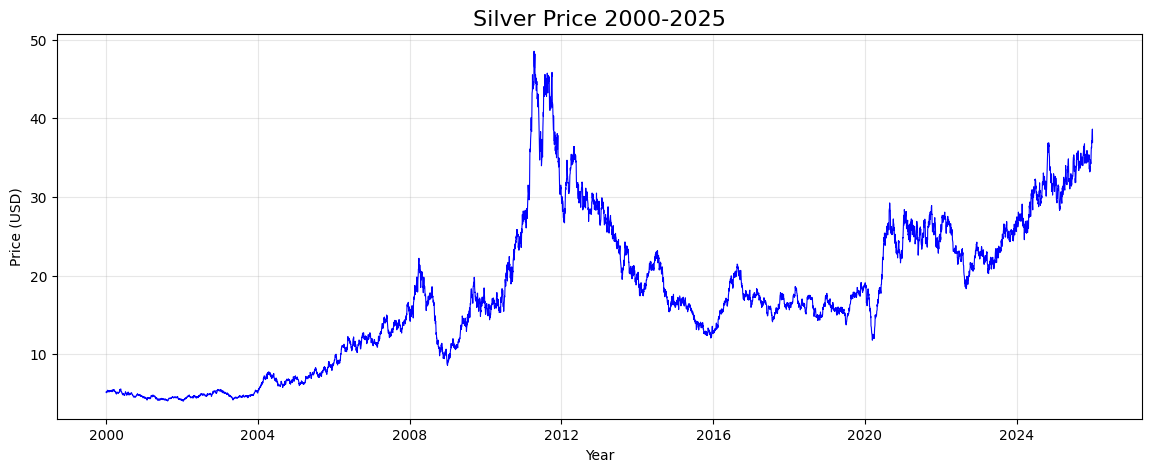

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(df['Date'], df['Close'], color='blue', linewidth=0.8)
plt.title('Silver Price 2000-2025', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Outliers Check
mean = df['Close'].mean()
std = df['Close'].std()
outliers = df[df['Close'] > mean + 4*std]

print(f"Mean: {mean:.2f}")
print(f"Std: {std:.2f}")
print(f"Outlier threshold: {mean + 4*std:.2f}")
print(f"Outliers found: {len(outliers)}")
print(outliers[['Date','Close']])

Mean: 17.53
Std: 9.40
Outlier threshold: 55.12
Outliers found: 0
Empty DataFrame
Columns: [Date, Close]
Index: []


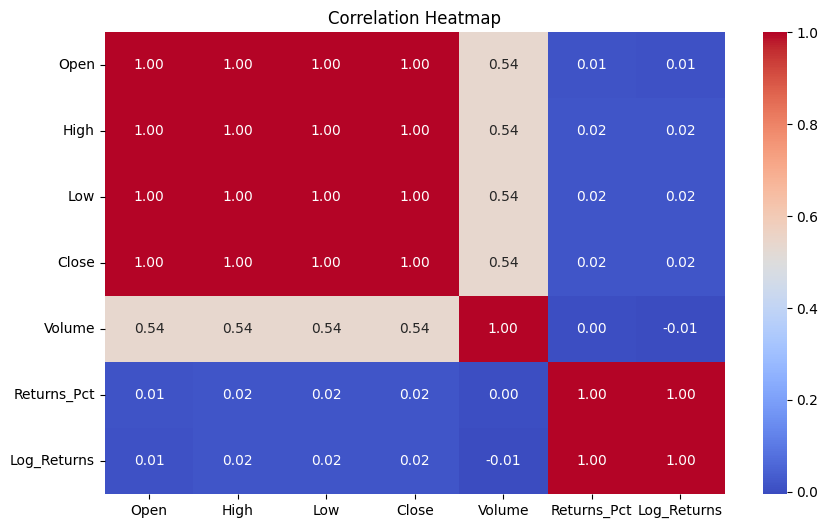

In [ ]:
import seaborn as sns

# Correlation Heatmap
numeric_cols = df[['Open','High','Low','Close','Volume','Returns_Pct','Log_Returns']]
plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Close'])
print(f"ADF Statistic: {result[0]:.4f}")
print(f"P-value: {result[1]:.4f}")

if result[1] < 0.05:
    print("✅ Data is STATIONARY")
else:
    print("❌ Data is NON-STATIONARY")

ADF Statistic: -1.3062
P-value: 0.6263
❌ Data is NON-STATIONARY


In [ ]:
from statsmodels.tsa.stattools import kpss

result = kpss(df['Close'])
print(f"KPSS Statistic: {result[0]:.4f}")
print(f"P-value: {result[1]:.4f}")

if result[1] < 0.05:
    print("❌ Data is NON-STATIONARY")
else:
    print("✅ Data is STATIONARY")

KPSS Statistic: 6.6248
P-value: 0.0100
❌ Data is NON-STATIONARY


/tmp/ipykernel_4678/2760511288.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(df['Close'])


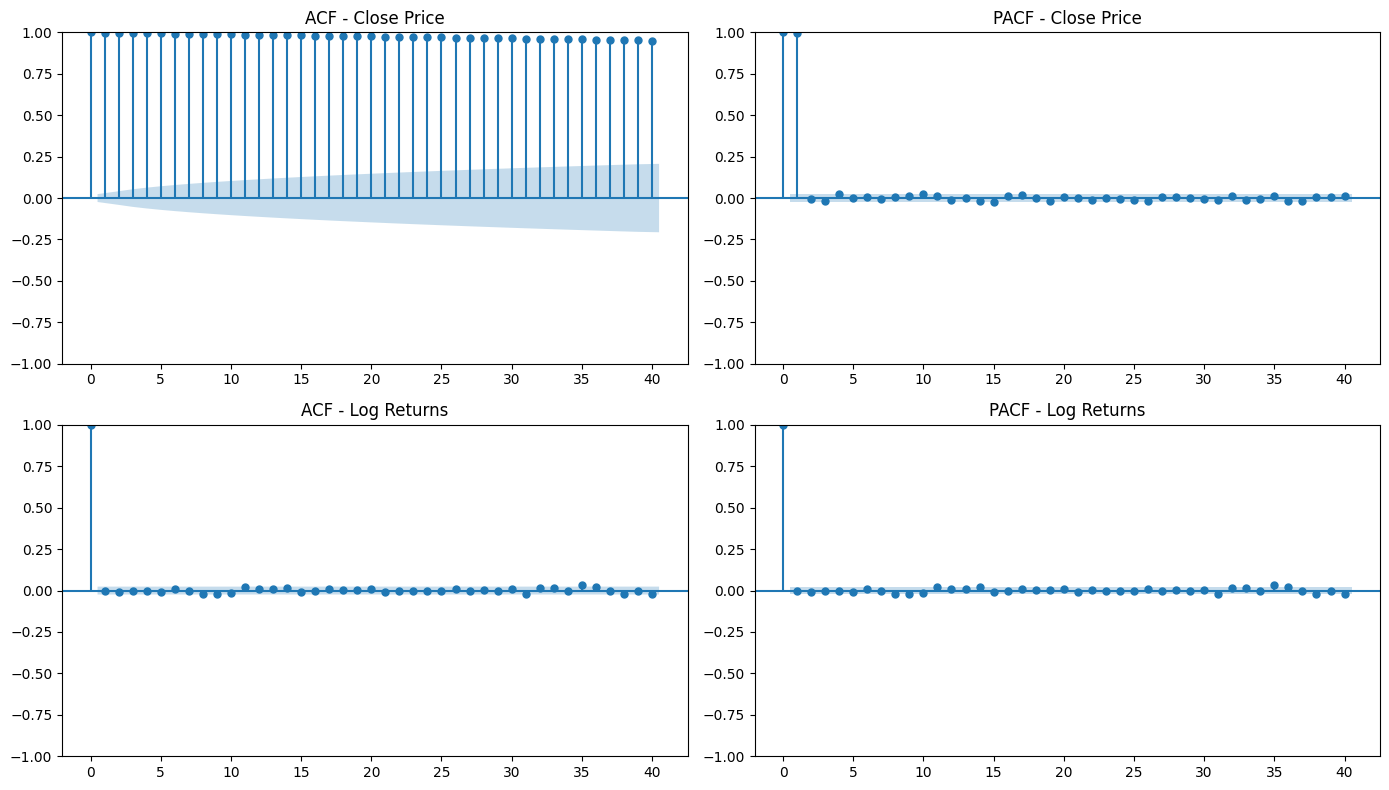

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ACF and PACF for Close price
plot_acf(df['Close'], lags=40, ax=axes[0][0], title='ACF - Close Price')
plot_pacf(df['Close'], lags=40, ax=axes[0][1], title='PACF - Close Price')

# ACF and PACF for Log Returns
plot_acf(df['Log_Returns'].dropna(), lags=40, ax=axes[1][0], title='ACF - Log Returns')
plot_pacf(df['Log_Returns'].dropna(), lags=40, ax=axes[1][1], title='PACF - Log Returns')

plt.tight_layout()
plt.show()

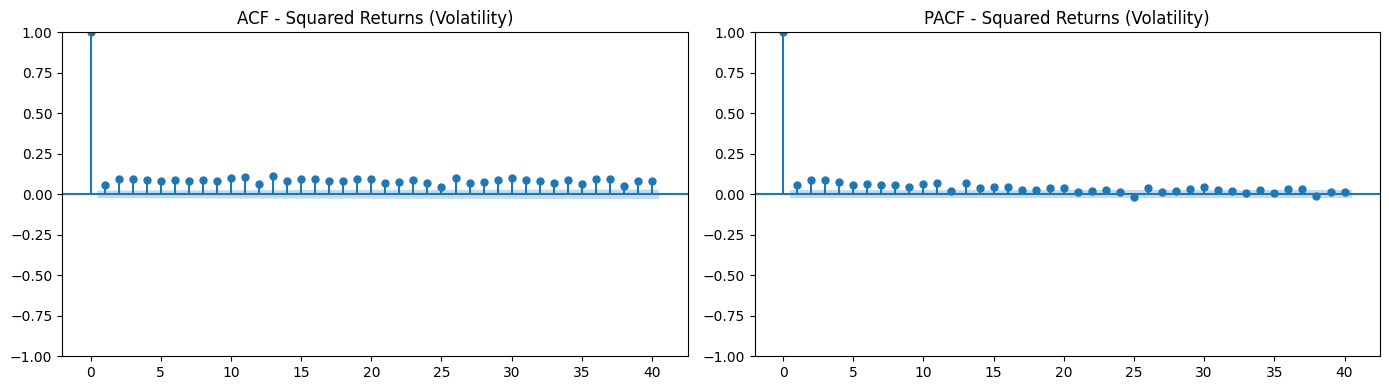

In [ ]:
# 1. Calculate Squared Returns
df['Squared_Returns'] = df['Log_Returns'] ** 2

# 2. Plot ACF and PACF for Squared Returns
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(df['Squared_Returns'].dropna(), lags=40, ax=axes[0], title='ACF - Squared Returns (Volatility)')
plot_pacf(df['Squared_Returns'].dropna(), lags=40, ax=axes[1], title='PACF - Squared Returns (Volatility)')

plt.tight_layout()
plt.show()

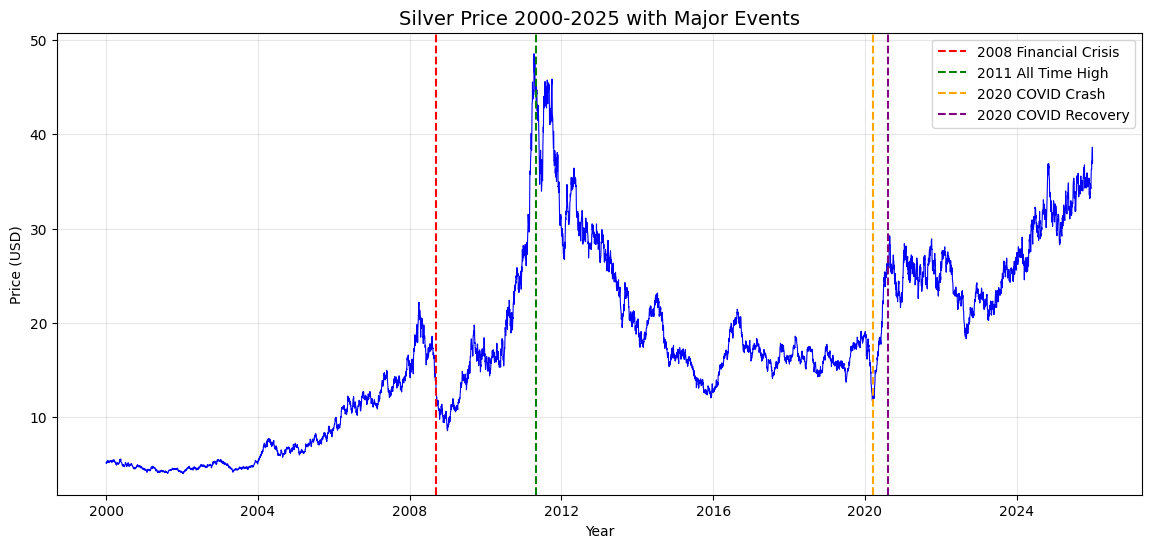

In [ ]:
# Silver Price with Major Events
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Close'], color='blue', linewidth=0.8)

# Mark important events
plt.axvline(x=pd.Timestamp('2008-09-15'), color='red', linestyle='--', label='2008 Financial Crisis')
plt.axvline(x=pd.Timestamp('2011-04-28'), color='green', linestyle='--', label='2011 All Time High')
plt.axvline(x=pd.Timestamp('2020-03-18'), color='orange', linestyle='--', label='2020 COVID Crash')
plt.axvline(x=pd.Timestamp('2020-08-07'), color='purple', linestyle='--', label='2020 COVID Recovery')

plt.title('Silver Price 2000-2025 with Major Events', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# Day 2 - Train/Val/Test Split
train = df[df['Date'] <= '2017-12-31']
val = df[(df['Date'] > '2017-12-31') & (df['Date'] <= '2020-12-31')]
test = df[df['Date'] > '2020-12-31']

print(f"Train: {len(train)} rows (2000-2017)")
print(f"Validation: {len(val)} rows (2018-2020)")
print(f"Test: {len(test)} rows (2021-2025)")

Train: 4695 rows (2000-2017)
Validation: 784 rows (2018-2020)
Test: 1304 rows (2021-2025)


In [ ]:
# Check missing values in all dataframes
print("Main data missing:", df.isnull().sum().sum())
print("Futures missing:", df_futures.isnull().sum().sum())
print("Sentiment missing:", df_sentiment.isnull().sum().sum())
print("Supply missing:", df_supply.isnull().sum().sum())
print("Macro missing:", df_macro.isnull().sum().sum())

Main data missing: 0
Futures missing: 0
Sentiment missing: 0
Supply missing: 0
Macro missing: 0


In [ ]:
# Step 1: load_data function
def load_data(path):
    df_main = pd.read_csv(path + 'silver_daily_ohlcv_2000_2025.csv')
    df_futures = pd.read_csv(path + 'silver_futures_contracts.csv')
    df_sentiment = pd.read_csv(path + 'silver_sentiment_weekly.csv')
    df_supply = pd.read_csv(path + 'silver_supply_demand_annual.csv')
    df_macro = pd.read_csv(path + 'silver_macroeconomic_monthly.csv')

    print("✅ All data loaded!")
    return df_main, df_futures, df_sentiment, df_supply, df_macro

# Call the function
df, df_futures, df_sentiment, df_supply, df_macro = load_data(path)
print("Done!")

✅ All data loaded!
Done!


In [ ]:
# Step 2: clean_data function
def clean_data(df_main, df_futures, df_sentiment, df_supply, df_macro):

    # Convert dates
    df_main['Date'] = pd.to_datetime(df_main['Date'], dayfirst=True)
    df_futures['Trade_Date'] = pd.to_datetime(df_futures['Trade_Date'])
    df_sentiment['Week_Ending'] = pd.to_datetime(df_sentiment['Week_Ending'], errors='coerce')
    df_supply['Year'] = pd.to_datetime(df_supply['Year'], format='%Y')
    df_macro['Date'] = pd.to_datetime(df_macro['Date'])

    # Sort main data
    df_main = df_main.sort_values('Date').reset_index(drop=True)

    # Drop null dates
    df_sentiment = df_sentiment.dropna(subset=['Week_Ending'])

    print("✅ Dates converted!")
    print("✅ Data cleaned!")

    return df_main, df_futures, df_sentiment, df_supply, df_macro

# Call function
df, df_futures, df_sentiment, df_supply, df_macro = clean_data(df, df_futures, df_sentiment, df_supply, df_macro)
print("Done!")

✅ Dates converted!
✅ Data cleaned!
Done!


In [ ]:
# Step 3: merge_sources function
def merge_sources(df_main, df_futures, df_sentiment, df_supply, df_macro):

    df_merged = df_main.copy()

    # Merge futures
    df_merged = pd.merge(df_merged,
                         df_futures[['Trade_Date','Futures_Price','Basis']],
                         left_on='Date', right_on='Trade_Date',
                         how='left')

    # Merge macro (forward fill - monthly to daily)
    df_merged = pd.merge(df_merged,
                         df_macro[['Date','Fed_Funds_Rate','DXY_Index',
                                   'Gold_Price_USD','VIX_Index','US_CPI_YoY_Pct']],
                         on='Date', how='left')
    df_merged['Fed_Funds_Rate'] = df_merged['Fed_Funds_Rate'].ffill()
    df_merged['DXY_Index'] = df_merged['DXY_Index'].ffill()
    df_merged['Gold_Price_USD'] = df_merged['Gold_Price_USD'].ffill()
    df_merged['VIX_Index'] = df_merged['VIX_Index'].ffill()
    df_merged['US_CPI_YoY_Pct'] = df_merged['US_CPI_YoY_Pct'].ffill()

    # Merge sentiment
    df_merged = pd.merge_asof(df_merged.sort_values('Date'),
                              df_sentiment[['Week_Ending','News_Sentiment_Score',
                                           'Google_Trends_Index']].sort_values('Week_Ending'),
                              left_on='Date', right_on='Week_Ending',
                              direction='backward')

    print(f"✅ Merged shape: {df_merged.shape}")
    return df_merged

# Call function
df_merged = merge_sources(df, df_futures, df_sentiment, df_supply, df_macro)
print("Done!")

✅ Merged shape: (28695, 24)
Done!


In [ ]:
# Step 4: scale_data function
from sklearn.preprocessing import MinMaxScaler, RobustScaler

def scale_data(train, val, test):

    # MinMaxScaler
    minmax = MinMaxScaler()
    train_minmax = minmax.fit_transform(train[['Close']])
    val_minmax = minmax.transform(val[['Close']])
    test_minmax = minmax.transform(test[['Close']])

    # RobustScaler
    robust = RobustScaler()
    train_robust = robust.fit_transform(train[['Close']])
    val_robust = robust.transform(val[['Close']])
    test_robust = robust.transform(test[['Close']])

    print("✅ MinMaxScaler done!")
    print(f"   Range: {train_minmax.min():.3f} to {train_minmax.max():.3f}")
    print("✅ RobustScaler done!")
    print(f"   Range: {train_robust.min():.3f} to {train_robust.max():.3f}")

    return minmax, robust, train_minmax, val_minmax, test_minmax, train_robust, val_robust, test_robust

# First split data
train = df_merged[df_merged['Date'] <= '2017-12-31']
val = df_merged[(df_merged['Date'] > '2017-12-31') & (df_merged['Date'] <= '2020-12-31')]
test = df_merged[df_merged['Date'] > '2020-12-31']

print(f"Train: {len(train)} rows")
print(f"Validation: {len(val)} rows")
print(f"Test: {len(test)} rows")

# Call scale function
minmax, robust, train_minmax, val_minmax, test_minmax, train_robust, val_robust, test_robust = scale_data(train, val, test)

Train: 18255 rows
Validation: 3920 rows
Test: 6520 rows
✅ MinMaxScaler done!
   Range: 0.000 to 1.000
✅ RobustScaler done!
   Range: -1.370 to 3.604


In [ ]:
# Step 5: Sequence Generator for LSTM
def create_sequences(data, lookback=60, horizon=1):
    X, y = [], []
    for i in range(lookback, len(data) - horizon + 1):
        X.append(data[i-lookback:i])
        y.append(data[i:i+horizon])
    return np.array(X), np.array(y)

# Create sequences with different lookbacks
print("Creating sequences...")

# 60 day lookback, 1 day forecast
X_train_60, y_train_60 = create_sequences(train_minmax, lookback=60, horizon=1)
X_val_60, y_val_60 = create_sequences(val_minmax, lookback=60, horizon=1)
X_test_60, y_test_60 = create_sequences(test_minmax, lookback=60, horizon=1)

print(f"✅ Lookback 60, Horizon 1:")
print(f"   X_train: {X_train_60.shape}")
print(f"   X_val: {X_val_60.shape}")
print(f"   X_test: {X_test_60.shape}")


Creating sequences...
✅ Lookback 60, Horizon 1:
   X_train: (18195, 60, 1)
   X_val: (3860, 60, 1)
   X_test: (6460, 60, 1)


In [ ]:
# Step 6: XGBoost Data Pipeline
def create_xgboost_features(df):

    df_xgb = df.copy()

    # Lag features - prevent data leakage
    for lag in [1, 2, 3, 5, 10, 20]:
        df_xgb[f'Close_lag_{lag}'] = df_xgb['Close'].shift(lag)
        df_xgb[f'Return_lag_{lag}'] = df_xgb['Log_Returns'].shift(lag)

    # Rolling features
    df_xgb['Rolling_Mean_5'] = df_xgb['Close'].shift(1).rolling(5).mean()
    df_xgb['Rolling_Mean_20'] = df_xgb['Close'].shift(1).rolling(20).mean()
    df_xgb['Rolling_Std_5'] = df_xgb['Close'].shift(1).rolling(5).std()
    df_xgb['Rolling_Std_20'] = df_xgb['Close'].shift(1).rolling(20).std()

    # Drop NaN rows
    df_xgb = df_xgb.dropna()

    print(f"✅ XGBoost features created!")
    print(f"   Shape: {df_xgb.shape}")
    print(f"   Total features: {df_xgb.shape[1]}")

    return df_xgb

# Call function
df_xgb = create_xgboost_features(df_merged)
print("Done!")

✅ XGBoost features created!
   Shape: (26065, 40)
   Total features: 40
Done!


In [ ]:
# Step 7: Save all preprocessed data
import pickle

def save_data(path):

    # Save splits
    with open(path + 'train.pkl', 'wb') as f:
        pickle.dump(train, f)
    with open(path + 'val.pkl', 'wb') as f:
        pickle.dump(val, f)
    with open(path + 'test.pkl', 'wb') as f:
        pickle.dump(test, f)

    # Save scaled data
    with open(path + 'train_minmax.pkl', 'wb') as f:
        pickle.dump(train_minmax, f)
    with open(path + 'train_robust.pkl', 'wb') as f:
        pickle.dump(train_robust, f)

    # Save scalers
    with open(path + 'minmax_scaler.pkl', 'wb') as f:
        pickle.dump(minmax, f)
    with open(path + 'robust_scaler.pkl', 'wb') as f:
        pickle.dump(robust, f)

    # Save sequences
    with open(path + 'X_train_60.pkl', 'wb') as f:
        pickle.dump(X_train_60, f)
    with open(path + 'y_train_60.pkl', 'wb') as f:
        pickle.dump(y_train_60, f)

    # Save XGBoost data
    with open(path + 'df_xgb.pkl', 'wb') as f:
        pickle.dump(df_xgb, f)

    # Save merged data
    df_merged.to_csv(path + 'silver_merged.csv', index=False)

    print("✅ All data saved to Google Drive!")

# Call function
save_data(path)

✅ All data saved to Google Drive!


In [ ]:
def create_technical_indicators(df):
    df_tech = df.copy()

    # 1. SMA - Simple Moving Average
    df_tech['SMA_20'] = df_tech['Close'].rolling(20).mean()
    df_tech['SMA_50'] = df_tech['Close'].rolling(50).mean()

    # 2. EMA - Exponential Moving Average
    df_tech['EMA_20'] = df_tech['Close'].ewm(span=20).mean()
    df_tech['EMA_50'] = df_tech['Close'].ewm(span=50).mean()

    # 3. MACD
    exp1 = df_tech['Close'].ewm(span=12).mean()
    exp2 = df_tech['Close'].ewm(span=26).mean()
    df_tech['MACD'] = exp1 - exp2
    df_tech['MACD_Signal'] = df_tech['MACD'].ewm(span=9).mean()
    df_tech['MACD_Histogram'] = df_tech['MACD'] - df_tech['MACD_Signal']

    # 4. RSI
    delta = df_tech['Close'].diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    df_tech['RSI'] = 100 - (100 / (1 + rs))

    # 5. Bollinger Bands
    df_tech['BB_Middle'] = df_tech['Close'].rolling(20).mean()
    df_tech['BB_Upper'] = df_tech['BB_Middle'] + 2*df_tech['Close'].rolling(20).std()
    df_tech['BB_Lower'] = df_tech['BB_Middle'] - 2*df_tech['Close'].rolling(20).std()
    df_tech['BB_Width'] = df_tech['BB_Upper'] - df_tech['BB_Lower']

    print("✅ SMA, EMA, MACD, RSI, Bollinger done!")
    return df_tech

df_tech = create_technical_indicators(df_merged)
print("Done!")

✅ SMA, EMA, MACD, RSI, Bollinger done!
Done!


In [ ]:
def add_more_indicators(df_tech):

    # 6. ATR - Average True Range
    df_tech['TR'] = np.maximum(
        df_tech['High'] - df_tech['Low'],
        np.maximum(
            abs(df_tech['High'] - df_tech['Close'].shift(1)),
            abs(df_tech['Low'] - df_tech['Close'].shift(1))
        )
    )
    df_tech['ATR'] = df_tech['TR'].rolling(14).mean()

    # 7. Stochastic Oscillator
    low_14 = df_tech['Low'].rolling(14).min()
    high_14 = df_tech['High'].rolling(14).max()
    df_tech['Stoch_K'] = 100 * (df_tech['Close'] - low_14) / (high_14 - low_14)
    df_tech['Stoch_D'] = df_tech['Stoch_K'].rolling(3).mean()

    # 8. ADX
    df_tech['DM_Plus'] = np.where(
        (df_tech['High'] - df_tech['High'].shift(1)) > (df_tech['Low'].shift(1) - df_tech['Low']),
        np.maximum(df_tech['High'] - df_tech['High'].shift(1), 0), 0)
    df_tech['DM_Minus'] = np.where(
        (df_tech['Low'].shift(1) - df_tech['Low']) > (df_tech['High'] - df_tech['High'].shift(1)),
        np.maximum(df_tech['Low'].shift(1) - df_tech['Low'], 0), 0)
    df_tech['DI_Plus'] = 100 * (df_tech['DM_Plus'].rolling(14).mean() / df_tech['ATR'])
    df_tech['DI_Minus'] = 100 * (df_tech['DM_Minus'].rolling(14).mean() / df_tech['ATR'])
    df_tech['ADX'] = 100 * abs(df_tech['DI_Plus'] - df_tech['DI_Minus']) / (df_tech['DI_Plus'] + df_tech['DI_Minus'])
    df_tech['ADX'] = df_tech['ADX'].rolling(14).mean()

    # 9. OBV - On Balance Volume
    df_tech['OBV'] = (np.sign(df_tech['Close'].diff()) * df_tech['Volume']).cumsum()

    # 10. VWAP
    df_tech['VWAP_Calc'] = (df_tech['Close'] * df_tech['Volume']).cumsum() / df_tech['Volume'].cumsum()

    print("✅ ATR, Stochastic, ADX, OBV, VWAP done!")
    return df_tech

df_tech = add_more_indicators(df_tech)
print("Done!")

✅ ATR, Stochastic, ADX, OBV, VWAP done!
Done!


In [ ]:
def add_ichimoku_fibonacci(df_tech):

    # 11. Ichimoku Cloud
    high_9 = df_tech['High'].rolling(9).max()
    low_9 = df_tech['Low'].rolling(9).min()
    high_26 = df_tech['High'].rolling(26).max()
    low_26 = df_tech['Low'].rolling(26).min()
    high_52 = df_tech['High'].rolling(52).max()
    low_52 = df_tech['Low'].rolling(52).min()

    df_tech['Ichimoku_Tenkan'] = (high_9 + low_9) / 2
    df_tech['Ichimoku_Kijun'] = (high_26 + low_26) / 2
    df_tech['Ichimoku_SpanA'] = ((df_tech['Ichimoku_Tenkan'] + df_tech['Ichimoku_Kijun']) / 2).shift(26)
    df_tech['Ichimoku_SpanB'] = ((high_52 + low_52) / 2).shift(26)

    # 12. Fibonacci Levels
    rolling_max = df_tech['Close'].rolling(60).max()
    rolling_min = df_tech['Close'].rolling(60).min()
    diff = rolling_max - rolling_min
    df_tech['Fib_236'] = rolling_max - 0.236 * diff
    df_tech['Fib_382'] = rolling_max - 0.382 * diff
    df_tech['Fib_618'] = rolling_max - 0.618 * diff

    print(f"✅ Ichimoku and Fibonacci done!")
    print(f"Total columns so far: {df_tech.shape[1]}")
    return df_tech

df_tech = add_ichimoku_fibonacci(df_tech)
print("Done!")

✅ Ichimoku and Fibonacci done!
Total columns so far: 54
Done!


In [ ]:
def create_lag_volatility_features(df_tech):

    # Lagged Return Features
    for lag in [1, 2, 3, 5, 10, 20, 60]:
        df_tech[f'Return_lag_{lag}'] = df_tech['Log_Returns'].shift(lag)
        df_tech[f'Close_lag_{lag}'] = df_tech['Close'].shift(lag)

    # Volatility Features - Rolling Std
    for window in [5, 10, 20, 60]:
        df_tech[f'Volatility_{window}'] = df_tech['Log_Returns'].rolling(window).std()

    # Parkinson Volatility
    df_tech['Parkinson_Vol'] = np.sqrt(
        (1/(4*np.log(2))) *
        ((np.log(df_tech['High']/df_tech['Low']))**2).rolling(20).mean()
    )

    print(f"✅ Lag features done!")
    print(f"✅ Volatility features done!")
    print(f"Total columns: {df_tech.shape[1]}")
    return df_tech

df_tech = create_lag_volatility_features(df_tech)
print("Done!")

✅ Lag features done!
✅ Volatility features done!
Total columns: 73
Done!


In [ ]:
def handle_multicollinearity(df_tech):

    # Select numeric columns only
    numeric_cols = df_tech.select_dtypes(include=[np.number]).columns.tolist()

    # Correlation matrix
    corr_matrix = df_tech[numeric_cols].corr().abs()

    # Find highly correlated features (>0.95)
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    # Drop columns with correlation > 0.95
    to_drop = [col for col in upper_triangle.columns
               if any(upper_triangle[col] > 0.95)]

    print(f"Total features before: {len(numeric_cols)}")
    print(f"Highly correlated features to drop: {len(to_drop)}")
    print(f"Features dropped: {to_drop[:10]}...")

    df_tech_clean = df_tech.drop(columns=to_drop)
    print(f"Total features after: {df_tech_clean.shape[1]}")

    return df_tech_clean, to_drop

df_tech_clean, dropped_features = handle_multicollinearity(df_tech)
print("Done!")

Total features before: 70
Highly correlated features to drop: 29
Features dropped: ['High', 'Low', 'Close', 'Adj_Close', 'VWAP', 'Log_Returns', 'Futures_Price', 'SMA_20', 'SMA_50', 'EMA_20']...
Total features after: 44
Done!


In [ ]:
print(df_tech_clean.columns.tolist())
print('Close' in df_tech_clean.columns)


['Date', 'Open', 'Volume', 'Returns_Pct', 'Dollar_Change', 'Intraday_Range', 'Intraday_Range_Pct', 'Trade_Date', 'Basis', 'Fed_Funds_Rate', 'DXY_Index', 'Gold_Price_USD', 'VIX_Index', 'US_CPI_YoY_Pct', 'Week_Ending', 'News_Sentiment_Score', 'Google_Trends_Index', 'MACD', 'MACD_Histogram', 'RSI', 'BB_Width', 'TR', 'ATR', 'Stoch_K', 'Stoch_D', 'DM_Plus', 'DM_Minus', 'DI_Plus', 'DI_Minus', 'ADX', 'OBV', 'VWAP_Calc', 'Return_lag_1', 'Return_lag_2', 'Return_lag_3', 'Return_lag_5', 'Return_lag_10', 'Return_lag_20', 'Return_lag_60', 'Volatility_5', 'Volatility_10', 'Volatility_20', 'Volatility_60', 'Parkinson_Vol']
False


In [ ]:
# Add Close column back
df_tech_clean['Close'] = df_tech['Close']

print('Close' in df_tech_clean.columns)
print(df_tech_clean['Close'].head())

True
0    5.1910
1    5.0980
2    5.1412
3    5.2239
4    5.2779
Name: Close, dtype: float64


In [ ]:
from sklearn.feature_selection import mutual_info_regression

def select_features(df_tech_clean):

    # Drop rows with NaN
    df_clean = df_tech_clean.dropna()

    # Target variable
    y = df_clean['Close']

    # Features - remove non-numeric and target
    exclude_cols = ['Date', 'Close', 'Trade_Date', 'Week_Ending']
    feature_cols = [col for col in df_clean.select_dtypes(include=[np.number]).columns
                    if col not in exclude_cols]

    X = df_clean[feature_cols]

    # Mutual Information
    mi_scores = mutual_info_regression(X, y, random_state=42)
    mi_df = pd.DataFrame({
        'Feature': feature_cols,
        'MI_Score': mi_scores
    }).sort_values('MI_Score', ascending=False)

    print("✅ Top 15 Most Important Features:")
    print(mi_df.head(15))

    return mi_df, feature_cols

mi_df, feature_cols = select_features(df_tech_clean)
print("Done!")

✅ Top 15 Most Important Features:
                 Feature  MI_Score
27                   OBV  8.629771
0                   Open  8.613978
1                 Volume  8.586448
35         Return_lag_60  8.571976
32          Return_lag_5  8.571289
34         Return_lag_20  8.571059
2            Returns_Pct  8.570618
33         Return_lag_10  8.570557
3          Dollar_Change  8.369152
5     Intraday_Range_Pct  8.350485
4         Intraday_Range  7.766215
28             VWAP_Calc  7.047851
29          Return_lag_1  6.779597
18                    TR  6.418497
12  News_Sentiment_Score  5.730935
Done!


<Figure size 1200x800 with 0 Axes>

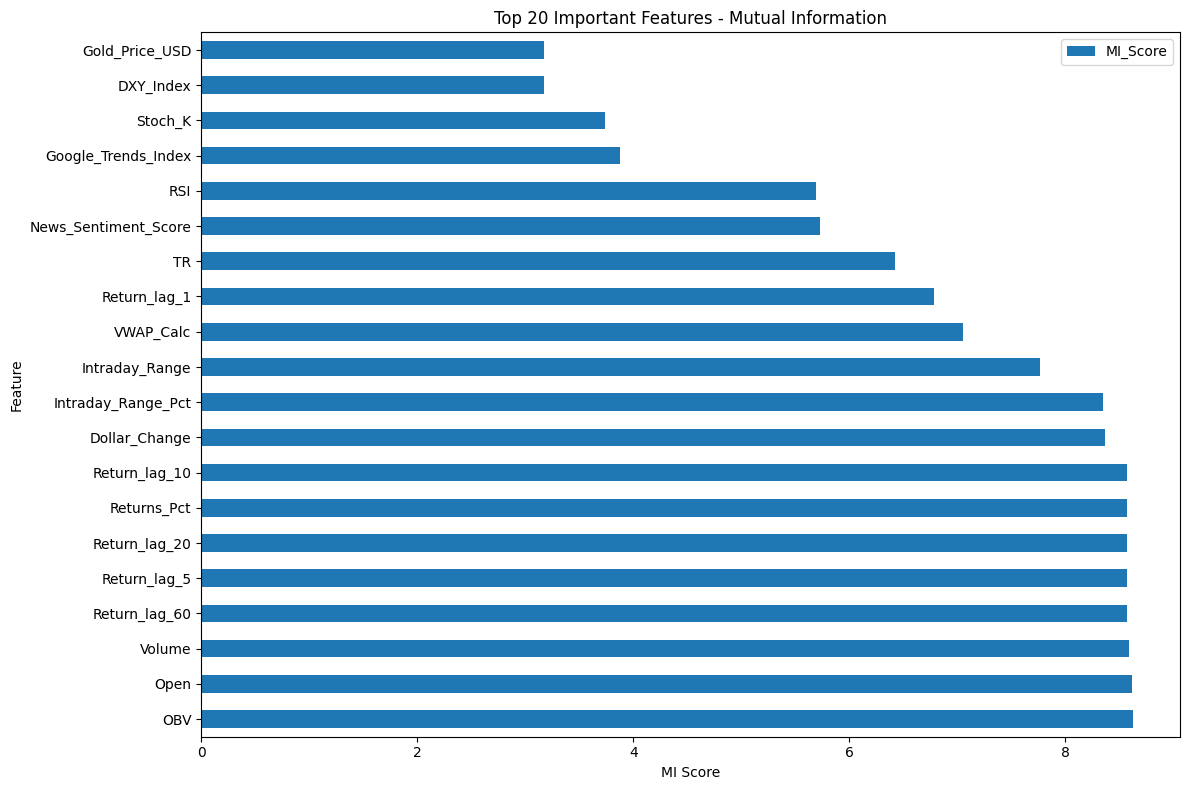

In [ ]:
# Plot top 20 features
plt.figure(figsize=(12,8))
mi_df.head(20).plot(x='Feature', y='MI_Score', kind='barh', figsize=(12,8))
plt.title('Top 20 Important Features - Mutual Information')
plt.xlabel('MI Score')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

def lasso_feature_selection(df_tech_clean):

    df_clean = df_tech_clean.dropna()

    exclude_cols = ['Date', 'Close', 'Trade_Date', 'Week_Ending']
    feature_cols = [col for col in df_clean.select_dtypes(include=[np.number]).columns
                    if col not in exclude_cols]

    X = df_clean[feature_cols]
    y = df_clean['Close']

    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # LASSO
    lasso = LassoCV(cv=5, random_state=42, max_iter=5000)
    lasso.fit(X_scaled, y)

    # Important features
    lasso_df = pd.DataFrame({
        'Feature': feature_cols,
        'Coefficient': abs(lasso.coef_)
    }).sort_values('Coefficient', ascending=False)

    print(f"✅ Best alpha: {lasso.alpha_:.6f}")
    print(f"✅ Features selected: {sum(lasso.coef_ != 0)}")
    print("\nTop 15 LASSO Features:")
    print(lasso_df[lasso_df['Coefficient'] > 0].head(15))

    return lasso_df

lasso_df = lasso_feature_selection(df_tech_clean)
print("Done!")

✅ Best alpha: 0.007578
✅ Features selected: 5

Top 15 LASSO Features:
           Feature  Coefficient
0             Open     7.568044
3    Dollar_Change     0.064281
27             OBV     0.000917
16             RSI     0.000815
9   Gold_Price_USD     0.000031
Done!


In [ ]:
# Save Day 3 features
def save_day3_data(path):

    # Save feature engineered data
    df_tech_clean.to_csv(path + 'silver_features.csv', index=False)

    # Save feature importance
    mi_df.to_csv(path + 'mutual_info_scores.csv', index=False)
    lasso_df.to_csv(path + 'lasso_scores.csv', index=False)

    # Save as pickle
    with open(path + 'df_tech_clean.pkl', 'wb') as f:
        pickle.dump(df_tech_clean, f)

    print("✅ All Day 3 data saved to Drive!")

save_day3_data(path)
print("Done!")

✅ All Day 3 data saved to Drive!
Done!


In [ ]:
def create_macro_features(df_tech_clean):

    df_macro_feat = df_tech_clean.copy()

    # 1. Real Interest Rate
    df_macro_feat['Real_Interest_Rate'] = df_macro_feat['Fed_Funds_Rate'] - df_macro_feat['US_CPI_YoY_Pct']

    # 2. Rate of Change - 3 month and 12 month
    df_macro_feat['Fed_Rate_3M_Change'] = df_macro_feat['Fed_Funds_Rate'].pct_change(63)
    df_macro_feat['Fed_Rate_12M_Change'] = df_macro_feat['Fed_Funds_Rate'].pct_change(252)

    # 3. Gold/Silver Ratio
    df_macro_feat['Gold_Silver_Ratio'] = df_macro_feat['Gold_Price_USD'] / df_macro_feat['Close']
    df_macro_feat['Gold_Silver_Ratio_SMA200'] = df_macro_feat['Gold_Silver_Ratio'].rolling(200).mean()

    # Gold/Silver Ratio Z-Score (3 year = 756 days)
    ratio_mean = df_macro_feat['Gold_Silver_Ratio'].rolling(756).mean()
    ratio_std = df_macro_feat['Gold_Silver_Ratio'].rolling(756).std()
    df_macro_feat['Gold_Silver_Ratio_Zscore'] = (df_macro_feat['Gold_Silver_Ratio'] - ratio_mean) / ratio_std

    # 4. Silver Price in INR
    df_macro_feat['Silver_INR_per_kg'] = df_macro_feat['Close'] * df_macro_feat['USD_INR'] * 32.1507

    print("✅ Real Interest Rate done!")
    print("✅ Gold/Silver Ratio features done!")
    print("✅ Silver INR price done!")

    return df_macro_feat

df_macro_feat = create_macro_features(df_tech_clean)
print("Done!")

KeyError: 'USD_INR'

In [ ]:
print('USD_INR' in df_tech_clean.columns)
print('USD_INR' in df_macro.columns)

In [ ]:
# Add USD_INR to df_tech_clean from df_macro
df_tech_clean = pd.merge(df_tech_clean,
                          df_macro[['Date', 'USD_INR']],
                          on='Date',
                          how='left')

df_tech_clean['USD_INR'] = df_tech_clean['USD_INR'].ffill()

print('USD_INR' in df_tech_clean.columns)
print(df_tech_clean['USD_INR'].head())

In [ ]:
df_macro_feat = create_macro_features(df_tech_clean)
print("Done!")

In [ ]:
def create_macro_regime(df_macro_feat):

    # VIX based crisis detection
    df_macro_feat['Crisis_Regime'] = (df_macro_feat['VIX_Index'] > 30).astype(int)

    # DXY momentum - is dollar strengthening?
    df_macro_feat['DXY_3M_Change'] = df_macro_feat['DXY_Index'].pct_change(63)

    # Macro Regime Classification
    conditions = [
        df_macro_feat['VIX_Index'] > 30,  # Crisis
        df_macro_feat['DXY_3M_Change'] < -0.02,  # Expansionary - dollar weakening
        df_macro_feat['DXY_3M_Change'] > 0.02,   # Contractionary - dollar strengthening
    ]
    choices = [2, 1, 0]  # 2=Crisis, 1=Expansionary, 0=Contractionary

    df_macro_feat['Macro_Regime'] = np.select(conditions, choices, default=1)

    print("✅ Macro Regime Classification done!")
    print(df_macro_feat['Macro_Regime'].value_counts())

    return df_macro_feat

df_macro_feat = create_macro_regime(df_macro_feat)
print("Done!")

In [ ]:
def create_sentiment_features(df_macro_feat, df_sentiment):

    # Ensure dates are correct
    df_sentiment_clean = df_sentiment.copy()
    df_sentiment_clean['Week_Ending'] = pd.to_datetime(df_sentiment_clean['Week_Ending'], errors='coerce')
    df_sentiment_clean = df_sentiment_clean.dropna(subset=['Week_Ending'])
    df_sentiment_clean = df_sentiment_clean.sort_values('Week_Ending')

    # COT Index = (Current - 3yr Min) / (3yr Max - 3yr Min)
    window_3yr = 156  # 3 years in weeks
    df_sentiment_clean['COT_3yr_Min'] = df_sentiment_clean['CFTC_NonCommercial_Net'].rolling(window_3yr).min()
    df_sentiment_clean['COT_3yr_Max'] = df_sentiment_clean['CFTC_NonCommercial_Net'].rolling(window_3yr).max()
    df_sentiment_clean['COT_Index'] = (
        (df_sentiment_clean['CFTC_NonCommercial_Net'] - df_sentiment_clean['COT_3yr_Min']) /
        (df_sentiment_clean['COT_3yr_Max'] - df_sentiment_clean['COT_3yr_Min'])
    )

    # Google Trends Momentum
    df_sentiment_clean['Trends_WoW_Change'] = df_sentiment_clean['Google_Trends_Index'].pct_change(1)
    df_sentiment_clean['Trends_4W_MA'] = df_sentiment_clean['Google_Trends_Index'].rolling(4).mean()

    # Merge with main data
    df_final = pd.merge_asof(
        df_macro_feat.sort_values('Date'),
        df_sentiment_clean[['Week_Ending', 'COT_Index', 'Trends_WoW_Change',
                            'Trends_4W_MA', 'CFTC_NonCommercial_Net',
                            'Implied_Volatility_30D']].sort_values('Week_Ending'),
        left_on='Date',
        right_on='Week_Ending',
        direction='backward'
    )

    print("✅ COT Index done!")
    print("✅ Google Trends features done!")
    print(f"Final shape: {df_final.shape}")

    return df_final

df_final = create_sentiment_features(df_macro_feat, df_sentiment)
print("Done!")

In [ ]:
from sklearn.ensemble import RandomForestRegressor

def random_forest_importance(df_final):

    # Clean data
    df_clean = df_final.dropna()

    # Exclude columns
    exclude_cols = ['Date', 'Close', 'Trade_Date', 'Week_Ending']
    feature_cols = [col for col in df_clean.select_dtypes(include=[np.number]).columns
                    if col not in exclude_cols]

    X = df_clean[feature_cols]
    y = df_clean['Close']

    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X, y)

    # Feature importance
    rf_df = pd.DataFrame({
        'Feature': feature_cols,
        'RF_Importance': rf.feature_importances_
    }).sort_values('RF_Importance', ascending=False)

    print("✅ Top 20 Features - Random Forest:")
    print(rf_df.head(20))

    return rf_df

rf_df = random_forest_importance(df_final)
print("Done!")

In [ ]:
def combined_feature_ranking(mi_df, rf_df):

    # Merge MI and RF scores
    combined = pd.merge(mi_df, rf_df, on='Feature', how='inner')

    # Normalize scores 0 to 1
    combined['MI_Normalized'] = (combined['MI_Score'] - combined['MI_Score'].min()) / \
                                  (combined['MI_Score'].max() - combined['MI_Score'].min())

    combined['RF_Normalized'] = (combined['RF_Importance'] - combined['RF_Importance'].min()) / \
                                  (combined['RF_Importance'].max() - combined['RF_Importance'].min())

    # Combined score
    combined['Combined_Score'] = (combined['MI_Normalized'] + combined['RF_Normalized']) / 2
    combined = combined.sort_values('Combined_Score', ascending=False)

    print("✅ Top 30 Features - Combined Ranking:")
    print(combined.head(30))

    # Plot
    plt.figure(figsize=(12,10))
    combined.head(20).plot(x='Feature', y='Combined_Score',
                           kind='barh', figsize=(12,10), color='teal')
    plt.title('Top 20 Features - Combined MI + RF Score')
    plt.xlabel('Combined Score')
    plt.tight_layout()
    plt.show()

    return combined

combined_ranking = combined_feature_ranking(mi_df, rf_df)
print("Done!")

In [ ]:
# Save Day 4 data
def save_day4_data(path):

    # Save final dataframe
    df_final.to_csv(path + 'silver_final_features.csv', index=False)

    # Save feature rankings
    combined_ranking.to_csv(path + 'combined_feature_ranking.csv', index=False)
    rf_df.to_csv(path + 'rf_importance.csv', index=False)

    # Save as pickle
    with open(path + 'df_final.pkl', 'wb') as f:
        pickle.dump(df_final, f)

    with open(path + 'combined_ranking.pkl', 'wb') as f:
        pickle.dump(combined_ranking, f)

    print("✅ All Day 4 data saved to Drive!")

save_day4_data(path)
print("Done!")

In [ ]:
print('Global_PMI' in df_final.columns)

In [ ]:
save_day4_data(path)
print("Done!")

In [ ]:
# Install pmdarima
!pip install pmdarima -q

from pmdarima import auto_arima
import warnings
warnings.filterwarnings('ignore')

# Use log returns for ARIMA
log_returns_train = train['Log_Returns'].dropna()

print("Running auto_arima...")

# Auto ARIMA
auto_model = auto_arima(
    log_returns_train,
    stepwise=True,
    seasonal=False,
    information_criterion='aic',
    max_p=5, max_q=5,
    max_d=2,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

print(f"\n✅ Best Model: ARIMA{auto_model.order}")
print(f"AIC: {auto_model.aic():.4f}")
print(f"BIC: {auto_model.bic():.4f}")

In [ ]:
# SARIMA with weekly seasonality s=5
print("Running SARIMA...")

sarima_model = auto_arima(
    log_returns_train,
    stepwise=True,
    seasonal=True,
    m=5,
    information_criterion='aic',
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    max_d=2, max_D=1,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

print(f"\n✅ Best SARIMA Model: {sarima_model.order}x{sarima_model.seasonal_order}")
print(f"AIC: {sarima_model.aic():.4f}")
print(f"BIC: {sarima_model.bic():.4f}")
print(f"\nARIMA AIC: {auto_model.aic():.4f}")
print(f"SARIMA AIC: {sarima_model.aic():.4f}")
print(f"Better model: {'SARIMA' if sarima_model.aic() < auto_model.aic() else 'ARIMA'}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
print(auto_model.order)

In [ ]:
create_macro_features

In [ ]:
create_macro_regime

In [ ]:
def create_macro_regime(df_macro_feat):

    # VIX based crisis detection
    df_macro_feat['Crisis_Regime'] = (df_macro_feat['VIX_Index'] > 30).astype(int)

    # DXY momentum
    df_macro_feat['DXY_3M_Change'] = df_macro_feat['DXY_Index'].pct_change(63)

    # Macro Regime Classification
    conditions = [
        df_macro_feat['VIX_Index'] > 30,
        df_macro_feat['DXY_3M_Change'] < -0.02,
        df_macro_feat['DXY_3M_Change'] > 0.02,
    ]
    choices = [2, 1, 0]

    df_macro_feat['Macro_Regime'] = np.select(conditions, choices, default=1)

    print("✅ Macro Regime Classification done!")
    print(df_macro_feat['Macro_Regime'].value_counts())

    return df_macro_feat

df_macro_feat = create_macro_regime(df_macro_feat)
print("Done!")

In [ ]:
import pickle

# Load Day 3 saved data
with open(path + 'df_tech_clean.pkl', 'rb') as f:
    df_tech_clean = pickle.load(f)

print("✅ df_tech_clean loaded!")
print(df_tech_clean.shape)

In [ ]:
df_macro_feat = create_macro_features(df_tech_clean)
print("Done!")

In [ ]:
# Add USD_INR to df_tech_clean from df_macro
df_tech_clean = pd.merge(df_tech_clean,
                          df_macro[['Date', 'USD_INR']],
                          on='Date',
                          how='left')

df_tech_clean['USD_INR'] = df_tech_clean['USD_INR'].ffill()
print("✅ USD_INR added!")

In [ ]:
df_macro_feat = create_macro_features(df_tech_clean)
print("Done!")

In [ ]:
df_macro_feat = create_macro_regime(df_macro_feat)
print("Done!")

In [ ]:
def create_macro_regime(df_macro_feat):

    df_macro_feat['Crisis_Regime'] = (df_macro_feat['VIX_Index'] > 30).astype(int)
    df_macro_feat['DXY_3M_Change'] = df_macro_feat['DXY_Index'].pct_change(63)

    conditions = [
        df_macro_feat['VIX_Index'] > 30,
        df_macro_feat['DXY_3M_Change'] < -0.02,
        df_macro_feat['DXY_3M_Change'] > 0.02,
    ]
    choices = [2, 1, 0]

    df_macro_feat['Macro_Regime'] = np.select(conditions, choices, default=1)

    print("✅ Macro Regime Classification done!")
    print(df_macro_feat['Macro_Regime'].value_counts())

    return df_macro_feat

df_macro_feat = create_macro_regime(df_macro_feat)
print("Done!")

In [ ]:
df_final = create_sentiment_features(df_macro_feat, df_sentiment)
print("Done!

In [ ]:
def create_sentiment_features(df_macro_feat, df_sentiment):

    df_sentiment_clean = df_sentiment.copy()
    df_sentiment_clean['Week_Ending'] = pd.to_datetime(df_sentiment_clean['Week_Ending'], errors='coerce')
    df_sentiment_clean = df_sentiment_clean.dropna(subset=['Week_Ending'])
    df_sentiment_clean = df_sentiment_clean.sort_values('Week_Ending')

    window_3yr = 156
    df_sentiment_clean['COT_3yr_Min'] = df_sentiment_clean['CFTC_NonCommercial_Net'].rolling(window_3yr).min()
    df_sentiment_clean['COT_3yr_Max'] = df_sentiment_clean['CFTC_NonCommercial_Net'].rolling(window_3yr).max()
    df_sentiment_clean['COT_Index'] = (
        (df_sentiment_clean['CFTC_NonCommercial_Net'] - df_sentiment_clean['COT_3yr_Min']) /
        (df_sentiment_clean['COT_3yr_Max'] - df_sentiment_clean['COT_3yr_Min'])
    )

    df_sentiment_clean['Trends_WoW_Change'] = df_sentiment_clean['Google_Trends_Index'].pct_change(1)
    df_sentiment_clean['Trends_4W_MA'] = df_sentiment_clean['Google_Trends_Index'].rolling(4).mean()

    df_final = pd.merge_asof(
        df_macro_feat.sort_values('Date'),
        df_sentiment_clean[['Week_Ending', 'COT_Index', 'Trends_WoW_Change',
                            'Trends_4W_MA', 'CFTC_NonCommercial_Net',
                            'Implied_Volatility_30D']].sort_values('Week_Ending'),
        left_on='Date',
        right_on='Week_Ending',
        direction='backward'
    )

    print("✅ COT Index done!")
    print("✅ Google Trends features done!")
    print(f"Final shape: {df_final.shape}")

    return df_final

df_final = create_sentiment_features(df_macro_feat, df_sentiment)
print("Done!")

In [ ]:
from sklearn.ensemble import RandomForestRegressor

def random_forest_importance(df_final):

    df_clean = df_final.dropna()

    exclude_cols = ['Date', 'Close', 'Trade_Date', 'Week_Ending']
    feature_cols = [col for col in df_clean.select_dtypes(include=[np.number]).columns
                    if col not in exclude_cols]

    X = df_clean[feature_cols]
    y = df_clean['Close']

    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X, y)

    rf_df = pd.DataFrame({
        'Feature': feature_cols,
        'RF_Importance': rf.feature_importances_
    }).sort_values('RF_Importance', ascending=False)

    print("✅ Top 20 Features - Random Forest:")
    print(rf_df.head(20))

    return rf_df

rf_df = random_forest_importance(df_final)
print("Done!")


In [ ]:
from sklearn.ensemble import RandomForestRegressor

def random_forest_importance(df_final):

    df_clean = df_final.dropna()

    exclude_cols = ['Date', 'Close', 'Trade_Date', 'Week_Ending']
    feature_cols = [col for col in df_clean.select_dtypes(include=[np.number]).columns
                    if col not in exclude_cols]

    X = df_clean[feature_cols]
    y = df_clean['Close']

    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X, y)

    rf_df = pd.DataFrame({
        'Feature': feature_cols,
        'RF_Importance': rf.feature_importances_
    }).sort_values('RF_Importance', ascending=False)

    print("✅ Top 20 Features - Random Forest:")
    print(rf_df.head(20))

    return rf_df

rf_df = random_forest_importance(df_final)
print("Done!")

In [ ]:
from pmdarima import auto_arima
import warnings
warnings.filterwarnings('ignore')

log_returns_train = train['Log_Returns'].dropna()

print("Running auto_arima...")

auto_model = auto_arima(
    log_returns_train,
    stepwise=True,
    seasonal=False,
    information_criterion='aic',
    max_p=5, max_q=5,
    max_d=2,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

print(f"\n✅ Best Model: ARIMA{auto_model.order}")
print(f"AIC: {auto_model.aic():.4f}")
print(f"BIC: {auto_model.bic():.4f}")


In [ ]:
import pickle

# Load all saved data
with open(path + 'df_tech_clean.pkl', 'rb') as f:
    df_tech_clean = pickle.load(f)

with open(path + 'df_final.pkl', 'rb') as f:
    df_final = pickle.load(f)

# Add USD_INR
df_tech_clean = pd.merge(df_tech_clean,
                          df_macro[['Date', 'USD_INR']],
                          on='Date', how='left')
df_tech_clean['USD_INR'] = df_tech_clean['USD_INR'].ffill()

# Split data
train = df_final[df_final['Date'] <= '2017-12-31']
val = df_final[(df_final['Date'] > '2017-12-31') & (df_final['Date'] <= '2020-12-31')]
test = df_final[df_final['Date'] > '2020-12-31']

print("✅ All data loaded!")
print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

NameError: name 'path' is not defined

In [ ]:
from pmdarima import auto_arima
import warnings
warnings.filterwarnings('ignore')

log_returns_train = train['Log_Returns'].dropna()

print("Running auto_arima...")

auto_model = auto_arima(
    log_returns_train,
    stepwise=True,
    seasonal=False,
    information_criterion='aic',
    max_p=5, max_q=5,
    max_d=2,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

print(f"\n✅ Best Model: ARIMA{auto_model.order}")
print(f"AIC: {auto_model.aic():.4f}")
print(f"BIC: {auto_model.bic():.4f}")


ModuleNotFoundError: No module named 'pmdarima'

In [ ]:
!pip install pmdarima -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.2 MB/s eta 0:00:00


In [ ]:
from pmdarima import auto_arima
import warnings
warnings.filterwarnings('ignore')

log_returns_train = train['Log_Returns'].dropna()

print("Running auto_arima...")

auto_model = auto_arima(
    log_returns_train,
    stepwise=True,
    seasonal=False,
    information_criterion='aic',
    max_p=5, max_q=5,
    max_d=2,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

print(f"\n✅ Best Model: ARIMA{auto_model.order}")
print(f"AIC: {auto_model.aic():.4f}")
print(f"BIC: {auto_model.bic():.4f}")


NameError: name 'train' is not defined

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from google.colab import drive

drive.mount('/content/drive')

path = '/content/drive/MyDrive/Silver_Project/'

# Load all saved data
with open(path + 'df_tech_clean.pkl', 'rb') as f:
    df_tech_clean = pickle.load(f)

with open(path + 'df_final.pkl', 'rb') as f:
    df_final = pickle.load(f)

# Load raw data for df_macro
df_macro = pd.read_csv(path + 'silver_macroeconomic_monthly.csv')
df_macro['Date'] = pd.to_datetime(df_macro['Date'])

# Add USD_INR
df_tech_clean = pd.merge(df_tech_clean,
                          df_macro[['Date', 'USD_INR']],
                          on='Date', how='left')
df_tech_clean['USD_INR'] = df_tech_clean['USD_INR'].ffill()

# Split data
train = df_final[df_final['Date'] <= '2017-12-31']
val = df_final[(df_final['Date'] > '2017-12-31') & (df_final['Date'] <= '2020-12-31')]
test = df_final[df_final['Date'] > '2020-12-31']

print("✅ All data loaded!")
print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

Mounted at /content/drive
✅ All data loaded!
Train: 18255, Val: 3920, Test: 6520


In [ ]:
from pmdarima import auto_arima
import warnings
warnings.filterwarnings('ignore')

log_returns_train = train['Log_Returns'].dropna()

print("Running auto_arima...")

auto_model = auto_arima(
    log_returns_train,
    stepwise=True,
    seasonal=False,
    information_criterion='aic',
    max_p=5, max_q=5,
    max_d=2,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

print(f"\n✅ Best Model: ARIMA{auto_model.order}")
print(f"AIC: {auto_model.aic():.4f}")
print(f"BIC: {auto_model.bic():.4f}")

KeyError: 'Log_Returns'

In [ ]:
print(train.columns.tolist())


['Date', 'Open', 'Volume', 'Returns_Pct', 'Dollar_Change', 'Intraday_Range', 'Intraday_Range_Pct', 'Trade_Date', 'Basis', 'Fed_Funds_Rate', 'DXY_Index', 'Gold_Price_USD', 'VIX_Index', 'US_CPI_YoY_Pct', 'Week_Ending_x', 'News_Sentiment_Score', 'Google_Trends_Index', 'MACD', 'MACD_Histogram', 'RSI', 'BB_Width', 'TR', 'ATR', 'Stoch_K', 'Stoch_D', 'DM_Plus', 'DM_Minus', 'DI_Plus', 'DI_Minus', 'ADX', 'OBV', 'VWAP_Calc', 'Return_lag_1', 'Return_lag_2', 'Return_lag_3', 'Return_lag_5', 'Return_lag_10', 'Return_lag_20', 'Return_lag_60', 'Volatility_5', 'Volatility_10', 'Volatility_20', 'Volatility_60', 'Parkinson_Vol', 'Close', 'USD_INR', 'Real_Interest_Rate', 'Fed_Rate_3M_Change', 'Fed_Rate_12M_Change', 'Gold_Silver_Ratio', 'Gold_Silver_Ratio_SMA200', 'Gold_Silver_Ratio_Zscore', 'Silver_INR_per_kg', 'Crisis_Regime', 'DXY_3M_Change', 'Macro_Regime', 'Week_Ending_y', 'COT_Index', 'Trends_WoW_Change', 'Trends_4W_MA', 'CFTC_NonCommercial_Net', 'Implied_Volatility_30D']


In [ ]:
# Load original data for Log_Returns
df_main = pd.read_csv(path + 'silver_daily_ohlcv_2000_2025.csv')
df_main['Date'] = pd.to_datetime(df_main['Date'], dayfirst=True)

# Add Log_Returns to df_final
df_final = pd.merge(df_final, df_main[['Date', 'Log_Returns']], on='Date', how='left')

# Re-split
train = df_final[df_final['Date'] <= '2017-12-31']
val = df_final[(df_final['Date'] > '2017-12-31') & (df_final['Date'] <= '2020-12-31')]
test = df_final[df_final['Date'] > '2020-12-31']

print("✅ Log_Returns added!")
print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")


✅ Log_Returns added!
Train: 18255, Val: 3920, Test: 6520


In [ ]:
from pmdarima import auto_arima
import warnings
warnings.filterwarnings('ignore')

log_returns_train = train['Log_Returns'].dropna()

print("Running auto_arima...")

auto_model = auto_arima(
    log_returns_train,
    stepwise=True,
    seasonal=False,
    information_criterion='aic',
    max_p=5, max_q=5,
    max_d=2,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

print(f"\n✅ Best Model: ARIMA{auto_model.order}")
print(f"AIC: {auto_model.aic():.4f}")
print(f"BIC: {auto_model.bic():.4f}")

Running auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-106560.082, Time=15.63 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-92164.002, Time=1.68 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-108637.082, Time=0.95 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-102047.964, Time=3.16 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-108676.626, Time=2.17 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=-108896.527, Time=4.15 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=-109279.604, Time=7.73 sec
 ARIMA(5,0,0)(0,0,0)[0]             : AIC=-109745.452, Time=5.89 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=-110572.338, Time=25.55 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=-109366.653, Time=19.84 sec
 ARIMA(5,0,2)(0,0,0)[0]             : AIC=-111089.481, Time=29.90 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=-108727.875, Time=22.43 sec
 ARIMA(5,0,3)(0,0,0)[0]             : AIC=-111645.985, Time=31.79 sec
 ARIMA(4,0,3)(0,0,0)[0]          

In [ ]:
print("Running SARIMA...")

sarima_model = auto_arima(
    log_returns_train,
    stepwise=True,
    seasonal=True,
    m=5,
    information_criterion='aic',
    max_p=2, max_q=2,
    max_P=1, max_Q=1,
    max_d=1, max_D=1,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

print(f"\n✅ Best SARIMA: {sarima_model.order}x{sarima_model.seasonal_order}")
print(f"AIC: {sarima_model.aic():.4f}")
print(f"Better model: {'SARIMA' if sarima_model.aic() < auto_model.aic() else 'ARIMA'}")

Running SARIMA...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[5] intercept   : AIC=-110436.903, Time=78.53 sec
 ARIMA(0,0,0)(0,0,0)[5] intercept   : AIC=-92164.943, Time=6.35 sec
 ARIMA(1,0,0)(1,0,0)[5] intercept   : AIC=-111584.760, Time=30.74 sec
 ARIMA(0,0,1)(0,0,1)[5] intercept   : AIC=-102454.974, Time=33.42 sec
 ARIMA(0,0,0)(0,0,0)[5]             : AIC=-92164.002, Time=0.81 sec
 ARIMA(1,0,0)(0,0,0)[5] intercept   : AIC=-108635.462, Time=2.75 sec
 ARIMA(1,0,0)(1,0,1)[5] intercept   : AIC=-112488.723, Time=49.16 sec
 ARIMA(1,0,0)(0,0,1)[5] intercept   : AIC=-112508.744, Time=66.94 sec
 ARIMA(0,0,0)(0,0,1)[5] intercept   : AIC=-92163.132, Time=5.16 sec
 ARIMA(2,0,0)(0,0,1)[5] intercept   : AIC=-112591.626, Time=72.53 sec
 ARIMA(2,0,0)(0,0,0)[5] intercept   : AIC=-108675.044, Time=6.90 sec
 ARIMA(2,0,0)(1,0,1)[5] intercept   : AIC=-112579.715, Time=65.27 sec
 ARIMA(2,0,0)(1,0,0)[5] intercept   : AIC=-111591.567, Time=52.43 sec
 ARIMA(2,0,1)(0,0,1)[5] intercept   :

In [ ]:
import itertools
from statsmodels.tsa.arima.model import ARIMA

p_values = range(0, 4)
d_values = range(0, 2)
q_values = range(0, 4)

best_aic = float('inf')
best_order = None
results = []

print("Running grid search...")

for p, d, q in itertools.product(p_values, d_values, q_values):
    try:
        model = ARIMA(log_returns_train, order=(p,d,q))
        result = model.fit()
        results.append({'p':p, 'd':d, 'q':q, 'AIC':result.aic})
        if result.aic < best_aic:
            best_aic = result.aic
            best_order = (p,d,q)
    except:
        continue

results_df = pd.DataFrame(results).sort_values('AIC')
print(f"✅ Best order: {best_order}")
print(f"✅ Best AIC: {best_aic:.4f}")
print(results_df.head(10))


Running grid search...
✅ Best order: (2, 0, 3)
✅ Best AIC: -110653.6945
    p  d  q            AIC
19  2  0  3 -110653.694548
27  3  0  3 -110182.522835
11  1  0  3 -109804.341238
31  3  1  3 -109691.251531
24  3  0  0 -108895.048501
25  3  0  1 -108803.167722
10  1  0  2 -108771.942721
16  2  0  0 -108675.044272
9   1  0  1 -108665.957396
23  2  1  3 -108664.948866


In [ ]:
# AIC Landscape
pivot_table = results_df.pivot_table(values='AIC', index='p', columns='q')

plt.figure(figsize=(10,6))
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd_r')
plt.title('ARIMA AIC Landscape (d=0)')
plt.xlabel('q')
plt.ylabel('p')
plt.show()

print("✅ AIC Landscape plotted!")

NameError: name 'sns' is not defined

<Figure size 1000x600 with 0 Axes>

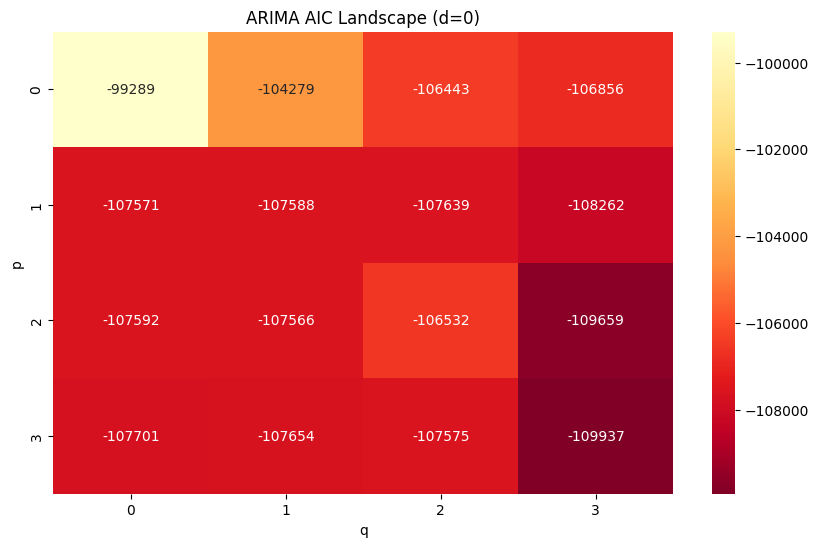

✅ AIC Landscape plotted!


In [ ]:
import seaborn as sns

# AIC Landscape
pivot_table = results_df.pivot_table(values='AIC', index='p', columns='q')

plt.figure(figsize=(10,6))
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd_r')
plt.title('ARIMA AIC Landscape (d=0)')
plt.xlabel('q')
plt.ylabel('p')
plt.show()

print("✅ AIC Landscape plotted!")


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

# Fit best model
best_model = ARIMA(log_returns_train, order=(2,0,3))
best_result = best_model.fit()
residuals = best_result.resid

# 1. Ljung-Box Test
lb_test = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print("=== Ljung-Box Test ===")
print(lb_test)
print("p-value > 0.05 = No autocorrelation in residuals ✅")

# 2. Jarque-Bera Test
jb_stat, jb_p = stats.jarque_bera(residuals)
print(f"\n=== Jarque-Bera Test ===")
print(f"Statistic: {jb_stat:.4f}")
print(f"P-value: {jb_p:.4f}")
print("p-value > 0.05 = Normal distribution ✅" if jb_p > 0.05 else "p-value < 0.05 = Not normal ❌")

print("\n✅ Residual diagnostics done!")


=== Ljung-Box Test ===
        lb_stat      lb_pvalue
10  1395.176011  1.091584e-293
20  1430.970110  2.546365e-291
p-value > 0.05 = No autocorrelation in residuals ✅

=== Jarque-Bera Test ===
Statistic: 36641.2780
P-value: 0.0000
p-value < 0.05 = Not normal ❌

✅ Residual diagnostics done!


In [ ]:
from statsmodels.stats.diagnostic import het_arch

# ARCH-LM Test
arch_test = het_arch(residuals, nlags=10)
print("=== ARCH-LM Test ===")
print(f"Statistic: {arch_test[0]:.4f}")
print(f"P-value: {arch_test[1]:.4f}")

if arch_test[1] < 0.05:
    print("ARCH effects detected! ❌ Need GARCH model!")
else:
    print("No ARCH effects ✅")


=== ARCH-LM Test ===
Statistic: 2653.2867
P-value: 0.0000
ARCH effects detected! ❌ Need GARCH model!


In [ ]:
!pip install arch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.8 MB/s eta 0:00:00


In [ ]:
from arch import arch_model

# ARIMA-GARCH(1,1)
garch_model = arch_model(
    log_returns_train * 100,  # Scale for better convergence
    mean='ARX',
    lags=2,
    vol='GARCH',
    p=1,
    q=1,
    dist='normal'
)

garch_result = garch_model.fit(disp='off')
print(garch_result.summary())
print("✅ ARIMA-GARCH(1,1) done!")


                           AR - GARCH Model Results                           
Dep. Variable:            Log_Returns   R-squared:                       0.595
Mean Model:                        AR   Adj. R-squared:                  0.595
Vol Model:                      GARCH   Log-Likelihood:               -29017.6
Distribution:                  Normal   AIC:                           58047.1
Method:            Maximum Likelihood   BIC:                           58094.0
                                        No. Observations:                18253
Date:                Fri, May 29 2026   Df Residuals:                    18250
Time:                        10:40:44   Df Model:                            3
                                    Mean Model                                   
                    coef    std err          t      P>|t|        95.0% Conf. Int.
---------------------------------------------------------------------------------
Const         4.2665e-03  8.975e-03      0.

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

# Walk-forward backtest
print("Running walk-forward backtest...")

log_returns_all = df_final['Log_Returns'].dropna().values
initial_window = 1000
predictions = []
actuals = []

for i in range(initial_window, initial_window + 500):  # 500 steps for speed
    try:
        train_wf = log_returns_all[:i]
        model = ARIMA(train_wf, order=(2,0,3))
        result = model.fit()
        pred = result.forecast(steps=1)[0]
        predictions.append(pred)
        actuals.append(log_returns_all[i])
    except:
        predictions.append(0)
        actuals.append(log_returns_all[i])

predictions = np.array(predictions)
actuals = np.array(actuals)

print("✅ Walk-forward backtest done!")
print(f"Total predictions: {len(predictions)}")

Running walk-forward backtest...
✅ Walk-forward backtest done!
Total predictions: 500


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Performance Metrics
rmse = np.sqrt(mean_squared_error(actuals, predictions))
mae = mean_absolute_error(actuals, predictions)
mape = np.mean(np.abs((actuals - predictions) / (actuals + 1e-10))) * 100

# Directional Accuracy
direction_actual = np.sign(actuals)
direction_pred = np.sign(predictions)
directional_accuracy = np.mean(direction_actual == direction_pred) * 100

# Maximum Absolute Error
max_error = np.max(np.abs(actuals - predictions))

print("=== PERFORMANCE METRICS ===")
print(f"RMSE: {rmse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"MAPE: {mape:.4f}%")
print(f"Directional Accuracy: {directional_accuracy:.2f}%")
print(f"Maximum Absolute Error: {max_error:.6f}")

=== PERFORMANCE METRICS ===
RMSE: 0.017878
MAE: 0.014435
MAPE: 114.9612%
Directional Accuracy: 52.80%
Maximum Absolute Error: 0.053327


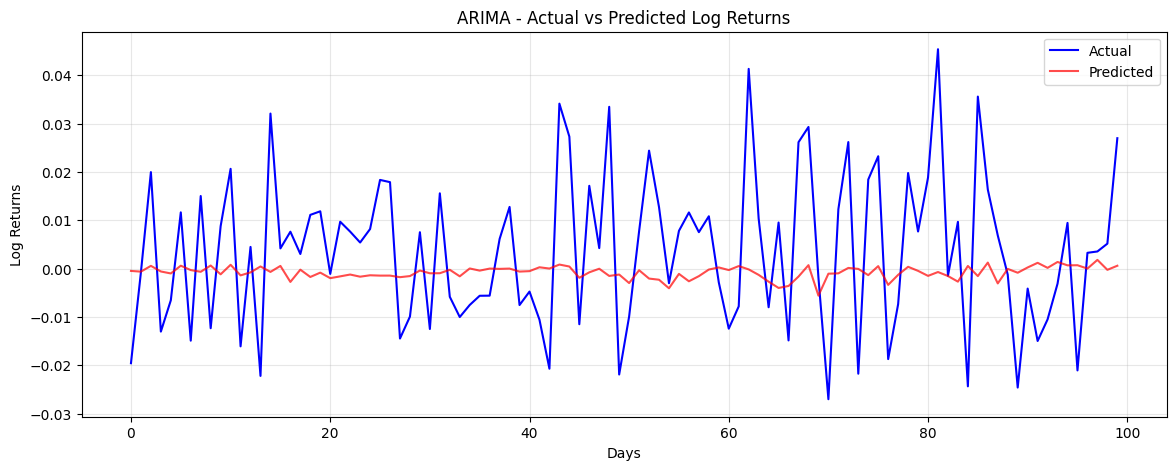

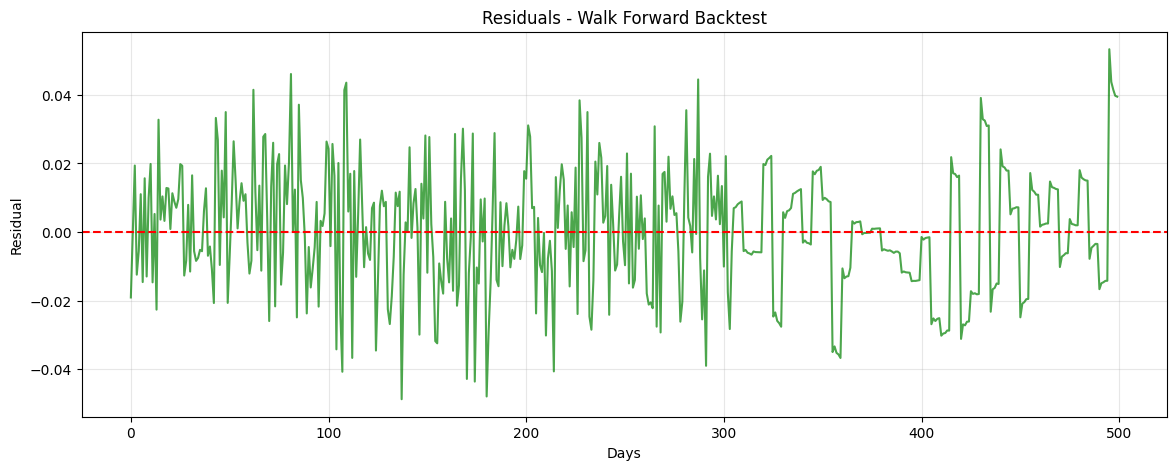

✅ Plots done!


In [ ]:
# Actual vs Predicted Plot
plt.figure(figsize=(14,5))
plt.plot(actuals[:100], label='Actual', color='blue')
plt.plot(predictions[:100], label='Predicted', color='red', alpha=0.7)
plt.title('ARIMA - Actual vs Predicted Log Returns')
plt.xlabel('Days')
plt.ylabel('Log Returns')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Residual Plot
residuals_wf = actuals - predictions
plt.figure(figsize=(14,5))
plt.plot(residuals_wf, color='green', alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals - Walk Forward Backtest')
plt.xlabel('Days')
plt.ylabel('Residual')
plt.grid(True, alpha=0.3)
plt.show()

print("✅ Plots done!")


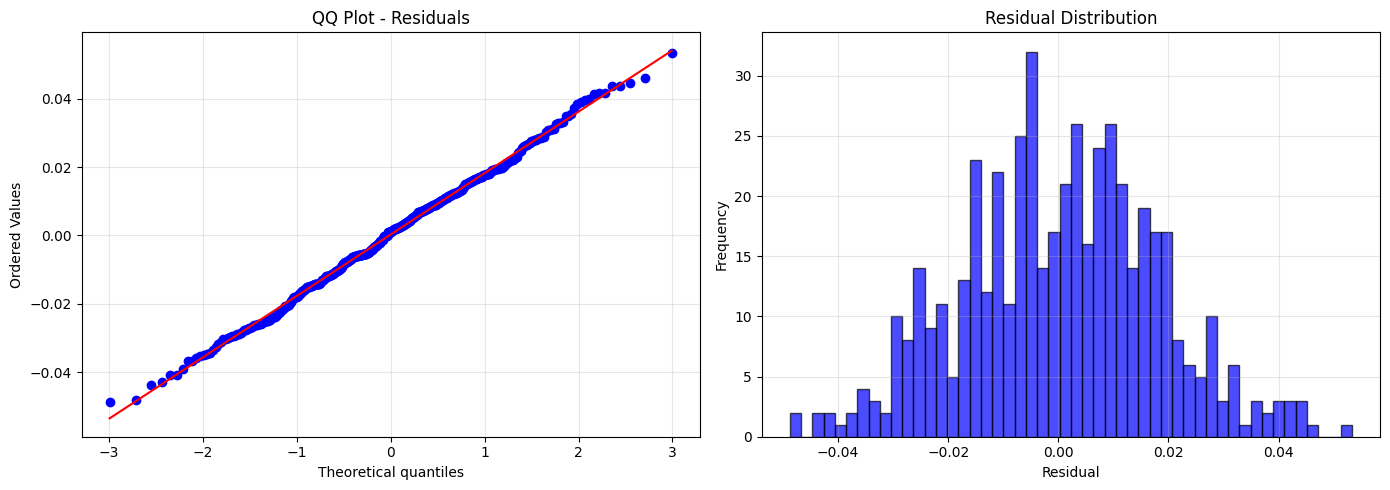

✅ QQ Plot done!


In [ ]:
from scipy import stats

# QQ Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# QQ Plot
stats.probplot(residuals_wf, dist="norm", plot=axes[0])
axes[0].set_title('QQ Plot - Residuals')
axes[0].grid(True, alpha=0.3)

# Residual Distribution
axes[1].hist(residuals_wf, bins=50, color='blue', alpha=0.7, edgecolor='black')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ QQ Plot done!")

In [ ]:
# Save Day 5 results
import pickle

# Save predictions and actuals
with open(path + 'arima_predictions.pkl', 'wb') as f:
    pickle.dump(predictions, f)

with open(path + 'arima_actuals.pkl', 'wb') as f:
    pickle.dump(actuals, f)

# Save metrics
metrics = {
    'RMSE': rmse,
    'MAE': mae,
    'MAPE': mape,
    'Directional_Accuracy': directional_accuracy,
    'Max_Error': max_error,
    'Best_ARIMA_Order': (2,0,3),
    'Best_SARIMA_Order': '(2,0,0)x(0,0,1,5)',
    'ARIMA_AIC': auto_model.aic(),
    'SARIMA_AIC': sarima_model.aic()
}

metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(path + 'arima_metrics.csv', index=False)

# Save models
with open(path + 'auto_model.pkl', 'wb') as f:
    pickle.dump(auto_model, f)
with open(path + 'garch_result.pkl', 'wb') as f:
    pickle.dump(garch_result, f)

print("✅ All Day 5 data saved to Drive!")


✅ All Day 5 data saved to Drive!


In [ ]:
!pip install prophet -q

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import warnings
warnings.filterwarnings('ignore')

# Prepare Prophet dataframe
df_prophet = df_final[['Date', 'Close', 'Gold_Price_USD',
                         'DXY_Index', 'VIX_Index', 'Real_Interest_Rate']].copy()

# Prophet requires ds and y columns
df_prophet = df_prophet.rename(columns={'Date': 'ds', 'Close': 'y'})

# Forward fill regressors
df_prophet['Gold_Price_USD'] = df_prophet['Gold_Price_USD'].ffill()
df_prophet['DXY_Index'] = df_prophet['DXY_Index'].ffill()
df_prophet['VIX_Index'] = df_prophet['VIX_Index'].ffill()
df_prophet['Real_Interest_Rate'] = df_prophet['Real_Interest_Rate'].ffill()

# Drop NaN
df_prophet = df_prophet.dropna()

print(f"✅ Prophet dataframe ready!")
print(f"Shape: {df_prophet.shape}")
print(df_prophet.head())


✅ Prophet dataframe ready!
Shape: (28695, 6)
          ds       y  Gold_Price_USD  DXY_Index  VIX_Index  Real_Interest_Rate
0 2000-01-03  5.1910          357.56     101.19       9.85                0.67
1 2000-01-04  5.0980          276.90     101.42      17.03                0.39
2 2000-01-05  5.1412          311.31     101.97       9.00               -0.40
3 2000-01-06  5.2239          414.39     101.32       9.00                2.40
4 2000-01-07  5.2779          286.72     101.72      15.86                1.09


In [ ]:
# Model 1 - Without regressors
print("Training Prophet without regressors...")

model1 = Prophet(
    changepoint_prior_scale=0.15,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

# Train on data till 2017
train_prophet = df_prophet[df_prophet['ds'] <= '2017-12-31']
model1.fit(train_prophet[['ds', 'y']])

print("✅ Prophet model 1 trained!")


Training Prophet without regressors...
✅ Prophet model 1 trained!


In [ ]:
# Model 2 - With regressors
print("Training Prophet with regressors...")

model2 = Prophet(
    changepoint_prior_scale=0.15,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

# Add regressors
model2.add_regressor('Gold_Price_USD')
model2.add_regressor('DXY_Index')
model2.add_regressor('VIX_Index')
model2.add_regressor('Real_Interest_Rate')

# Train
model2.fit(train_prophet)

print("✅ Prophet model 2 with regressors trained!")

Training Prophet with regressors...
✅ Prophet model 2 with regressors trained!


In [ ]:
# Make predictions - both models
test_prophet = df_prophet[df_prophet['ds'] > '2017-12-31']

# Model 1 predictions
future1 = model1.make_future_dataframe(periods=len(test_prophet))
forecast1 = model1.predict(future1)

# Model 2 predictions
future2 = model2.make_future_dataframe(periods=len(test_prophet))
future2['Gold_Price_USD'] = df_prophet['Gold_Price_USD'].values[-len(future2):]
future2['DXY_Index'] = df_prophet['DXY_Index'].values[-len(future2):]
future2['VIX_Index'] = df_prophet['VIX_Index'].values[-len(future2):]
future2['Real_Interest_Rate'] = df_prophet['Real_Interest_Rate'].values[-len(future2):]
future2 = future2.ffill()
forecast2 = model2.predict(future2)

print("✅ Both models predicted!")

✅ Both models predicted!


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Get test period predictions
test_dates = test_prophet['ds'].values
actual_test = test_prophet['y'].values

# Model 1 metrics
pred1 = forecast1[forecast1['ds'].isin(test_dates)]['yhat'].values[:len(actual_test)]
rmse1 = np.sqrt(mean_squared_error(actual_test, pred1))
mape1 = np.mean(np.abs((actual_test - pred1) / actual_test)) * 100

# Model 2 metrics
pred2 = forecast2[forecast2['ds'].isin(test_dates)]['yhat'].values[:len(actual_test)]
rmse2 = np.sqrt(mean_squared_error(actual_test, pred2))
mape2 = np.mean(np.abs((actual_test - pred2) / actual_test)) * 100

print("=== MODEL COMPARISON ===")
print(f"Without Regressors — RMSE: {rmse1:.4f}, MAPE: {mape1:.2f}%")
print(f"With Regressors    — RMSE: {rmse2:.4f}, MAPE: {mape2:.2f}%")
print(f"Better model: {'With Regressors' if rmse2 < rmse1 else 'Without Regressors'}")

ValueError: Found input variables with inconsistent numbers of samples: [10440, 2088]

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Get test period only
test_forecast1 = forecast1[forecast1['ds'] > '2017-12-31'].copy()
test_forecast2 = forecast2[forecast2['ds'] > '2017-12-31'].copy()

# Align lengths
min_len = min(len(test_prophet), len(test_forecast1), len(test_forecast2))

actual_test = test_prophet['y'].values[:min_len]
pred1 = test_forecast1['yhat'].values[:min_len]
pred2 = test_forecast2['yhat'].values[:min_len]

# Metrics
rmse1 = np.sqrt(mean_squared_error(actual_test, pred1))
mape1 = np.mean(np.abs((actual_test - pred1) / actual_test)) * 100

rmse2 = np.sqrt(mean_squared_error(actual_test, pred2))
mape2 = np.mean(np.abs((actual_test - pred2) / actual_test)) * 100

print("=== MODEL COMPARISON ===")
print(f"Without Regressors — RMSE: {rmse1:.4f}, MAPE: {mape1:.2f}%")
print(f"With Regressors    — RMSE: {rmse2:.4f}, MAPE: {mape2:.2f}%")
print(f"Better model: {'With Regressors' if rmse2 < rmse1 else 'Without Regressors'}")

=== MODEL COMPARISON ===
Without Regressors — RMSE: 8.3316, MAPE: 32.54%
With Regressors    — RMSE: 3.6480, MAPE: 13.74%
Better model: With Regressors


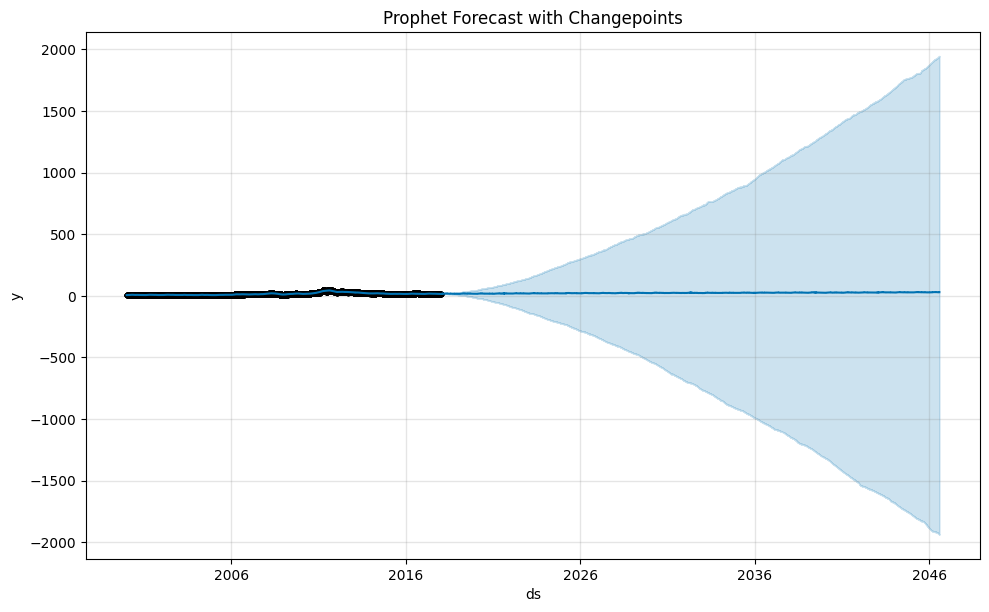

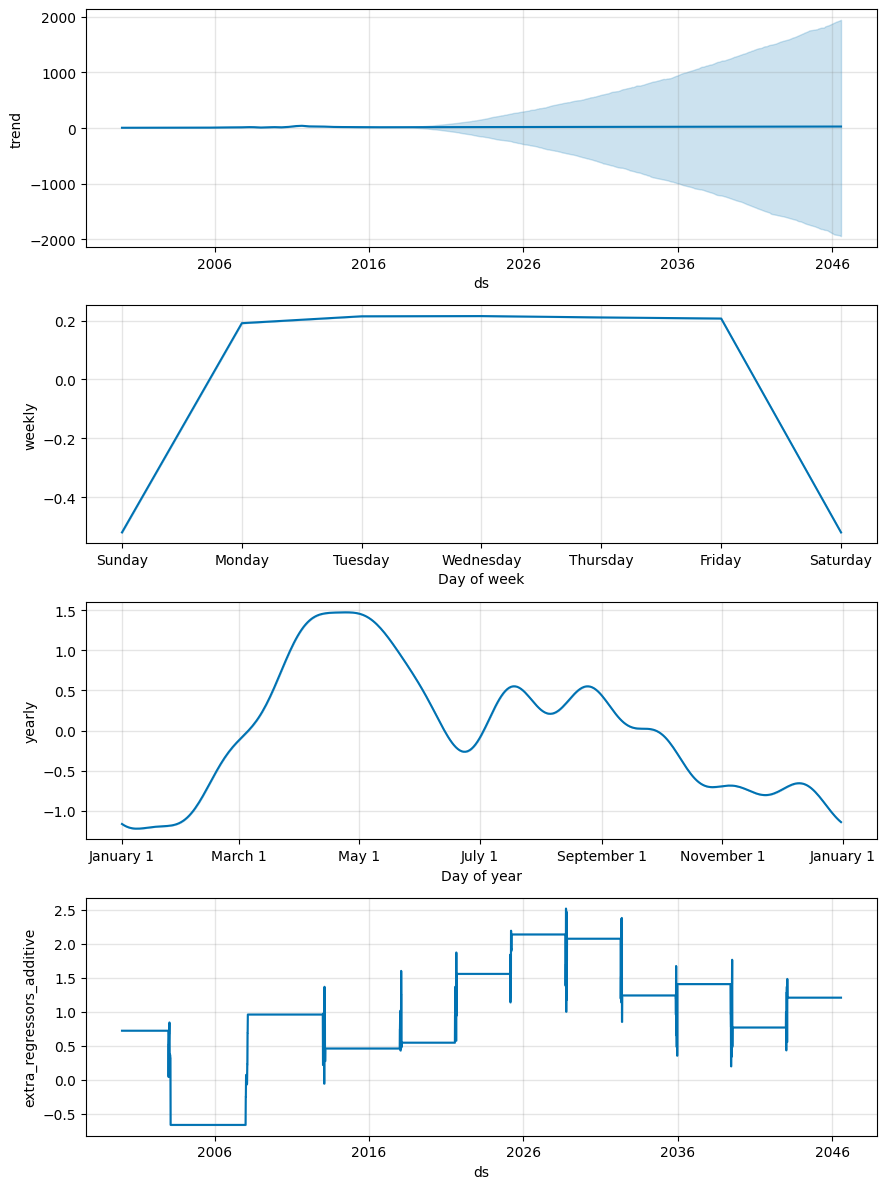

✅ Changepoint plots done!


In [ ]:
# Changepoint Plot
fig = model2.plot(forecast2)
plt.title('Prophet Forecast with Changepoints')
plt.show()

# Changepoint locations
fig2 = model2.plot_components(forecast2)
plt.show()

print("✅ Changepoint plots done!")

In [ ]:
from prophet.diagnostics import cross_validation, performance_metrics

print("Running Prophet cross-validation...")
print("This will take some time...")

# Cross validation
df_cv = cross_validation(
    model2,
    initial='3650 days',
    period='365 days',
    horizon='60 days',
    parallel=None
)

# Performance metrics
df_perf = performance_metrics(df_cv)

print("✅ Cross-validation done!")
print("\n=== CV PERFORMANCE METRICS ===")
print(df_perf[['horizon', 'rmse', 'mae', 'mape']].tail(10))


Running Prophet cross-validation...
This will take some time...


INFO:prophet:Making 8 forecasts with cutoffs between 2010-11-01 00:00:00 and 2017-10-30 00:00:00


  0%|          | 0/8 [00:00<?, ?it/s]

✅ Cross-validation done!

=== CV PERFORMANCE METRICS ===
   horizon      rmse       mae      mape
44 51 days  6.760638  3.680632  0.139046
45 52 days  7.442490  4.202041  0.156377
46 53 days  7.382725  4.220869  0.158956
47 54 days  6.666820  3.749968  0.146070
48 55 days  6.703430  3.738359  0.145658
49 56 days  6.670875  3.630702  0.139908
50 57 days  6.640606  3.603697  0.137489
51 58 days  6.644482  3.664406  0.138471
52 59 days  7.389769  4.186092  0.154441
53 60 days  7.352632  4.154638  0.152440


In [ ]:
# Save Day 6
df_cv.to_csv(path + 'prophet_cv_results.csv', index=False)
df_perf.to_csv(path + 'prophet_performance.csv', index=False)

prophet_metrics = {
    'Without_Regressors_RMSE': rmse1,
    'Without_Regressors_MAPE': mape1,
    'With_Regressors_RMSE': rmse2,
    'With_Regressors_MAPE': mape2
}

pd.DataFrame([prophet_metrics]).to_csv(path + 'prophet_metrics.csv', index=False)

import pickle
with open(path + 'prophet_model2.pkl', 'wb') as f:
    pickle.dump(model2, f)

print("✅ All Day 6 data saved!")


✅ All Day 6 data saved!


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np

print(f"TensorFlow version: {tf.__version__}")

# Select 15 features for multivariate LSTM
features = ['Close', 'Volume', 'RSI', 'MACD', 'ATR',
            'BB_Width', 'OBV', 'Gold_Price_USD', 'DXY_Index',
            'VIX_Index', 'Real_Interest_Rate', 'Return_lag_1',
            'Volatility_20', 'Gold_Silver_Ratio', 'COT_Index']

# Get data
df_lstm = df_final[['Date'] + features].dropna()

print(f"✅ Features selected: {len(features)}")
print(f"Shape: {df_lstm.shape}")


TensorFlow version: 2.20.0
✅ Features selected: 15
Shape: (16195, 16)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Scale all features
scaler_lstm = MinMaxScaler()

# Split first
train_lstm = df_lstm[df_lstm['Date'] <= '2017-12-31']
val_lstm = df_lstm[(df_lstm['Date'] > '2017-12-31') & (df_lstm['Date'] <= '2020-12-31')]
test_lstm = df_lstm[df_lstm['Date'] > '2020-12-31']

# Scale
train_scaled = scaler_lstm.fit_transform(train_lstm[features])
val_scaled = scaler_lstm.transform(val_lstm[features])
test_scaled = scaler_lstm.transform(test_lstm[features])

# Create sequences function
def create_multivariate_sequences(data, lookback=60):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i, 0])  # Close price = first feature
    return np.array(X), np.array(y)

# Create sequences with 60 day lookback
X_train, y_train = create_multivariate_sequences(train_scaled, lookback=60)
X_val, y_val = create_multivariate_sequences(val_scaled, lookback=60)
X_test, y_test = create_multivariate_sequences(test_scaled, lookback=60)

print(f"✅ Sequences created!")
print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")
print(f"X_test: {X_test.shape}")


✅ Sequences created!
X_train: (5695, 60, 15)
X_val: (3860, 60, 15)
X_test: (6460, 60, 15)


In [ ]:
# Architecture A - Single LSTM
def build_model_A(lookback, n_features):
    model = Sequential([
        LSTM(128, input_shape=(lookback, n_features)),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Callbacks
callbacks_A = [
    EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=5, verbose=1),
    ModelCheckpoint(path + 'model_A.h5', save_best_only=True, verbose=0)
]

# Build and train
model_A = build_model_A(60, len(features))
model_A.summary()

print("\nTraining Model A...")
history_A = model_A.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks_A,
    verbose=1
)

print("✅ Model A trained!")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,889 (304.25 KB)

 Trainable params: 77,889 (304.25 KB)

 Non-trainable params: 0 (0.00 B)

...

178/178 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step - loss: 2.5389e-04 - mae: 0.0116 - val_loss: 0.0031 - val_mae: 0.0385 - learning_rate: 0.0010
Epoch 7/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 16s 88ms/step - loss: 2.5462e-04 - mae: 0.0116 - val_loss: 0.0036 - val_mae: 0.0440 - learning_rate: 0.0010
Epoch 8/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 2.8013e-04 - mae: 0.0124

178/178 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step - loss: 2.4651e-04 - mae: 0.0114 - val_loss: 0.0025 - val_mae: 0.0332 - learning_rate: 0.0010
Epoch 9/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 2.4855e-04 - mae: 0.0118

178/178 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - loss: 2.3022e-04 - mae: 0.0111 - val_loss: 0.0023 - val_mae: 0.0320 - learning_rate: 0.0010
Epoch 10/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 16s 88ms/step - loss: 2.3049e-04 - mae: 0.0110 - val_loss: 0.0026 - val_mae: 0.0357 - learning_rate: 0.0010
Epoch 11/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 16s 89ms/step - loss: 2.3192e-04 - mae: 0.0112 - val_loss: 0.0024 - val_mae: 0.0323 - learning_rate: 0.0010
Epoch 12/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 2.6879e-04 - mae: 0.0124

178/178 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - loss: 2.6985e-04 - mae: 0.0123 - val_loss: 0.0016 - val_mae: 0.0272 - learning_rate: 0.0010
Epoch 13/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - loss: 2.1128e-04 - mae: 0.0104 - val_loss: 0.0024 - val_mae: 0.0355 - learning_rate: 0.0010
Epoch 14/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - loss: 1.9952e-04 - mae: 0.0101 - val_loss: 0.0019 - val_mae: 0.0299 - learning_rate: 0.0010
Epoch 15/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 1.8499e-04 - mae: 0.0096

178/178 ━━━━━━━━━━━━━━━━━━━━ 17s 96ms/step - loss: 1.9070e-04 - mae: 0.0098 - val_loss: 9.0845e-04 - val_mae: 0.0206 - learning_rate: 0.0010
Epoch 16/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 17s 94ms/step - loss: 2.0236e-04 - mae: 0.0103 - val_loss: 0.0022 - val_mae: 0.0340 - learning_rate: 0.0010
Epoch 17/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 20s 93ms/step - loss: 2.3089e-04 - mae: 0.0112 - val_loss: 0.0022 - val_mae: 0.0332 - learning_rate: 0.0010
Epoch 18/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 16s 89ms/step - loss: 2.2162e-04 - mae: 0.0107 - val_loss: 0.0017 - val_mae: 0.0303 - learning_rate: 0.0010
Epoch 19/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - loss: 1.8538e-04 - mae: 0.0094 - val_loss: 0.0011 - val_mae: 0.0234 - learning_rate: 0.0010
Epoch 20/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 1.9838e-04 - mae: 0.0103
Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
178/178 ━━━━━━━━━━━━━━━━━━━━ 18s 103ms/step - loss: 1.9000e-04 - mae: 0.0097 - val_loss: 0.001

In [ ]:
# Architecture B - Stacked LSTM
def build_model_B(lookback, n_features):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(lookback, n_features)),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

callbacks_B = [
    EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=5, verbose=1),
    ModelCheckpoint(path + 'model_B.h5', save_best_only=True, verbose=0)
]

model_B = build_model_B(60, len(features))
model_B.summary()

print("\nTraining Model B...")
history_B = model_B.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks_B,
    verbose=1
)

print("✅ Model B trained!")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 60, 128)        │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,249 (489.25 KB)

 Trainable params: 125,249 (489.25 KB)

 Non-trainable params: 0 (0.00 B)

...

178/178 ━━━━━━━━━━━━━━━━━━━━ 29s 163ms/step - loss: 0.0013 - mae: 0.0274 - val_loss: 0.0086 - val_mae: 0.0587 - learning_rate: 0.0010
Epoch 4/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 39s 149ms/step - loss: 0.0012 - mae: 0.0261 - val_loss: 0.0088 - val_mae: 0.0635 - learning_rate: 0.0010
Epoch 5/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 26s 148ms/step - loss: 0.0011 - mae: 0.0253 - val_loss: 0.0092 - val_mae: 0.0630 - learning_rate: 0.0010
Epoch 6/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 25s 140ms/step - loss: 9.4943e-04 - mae: 0.0229 - val_loss: 0.0088 - val_mae: 0.0631 - learning_rate: 0.0010
Epoch 7/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 8.0030e-04 - mae: 0.0211

178/178 ━━━━━━━━━━━━━━━━━━━━ 24s 132ms/step - loss: 8.5654e-04 - mae: 0.0219 - val_loss: 0.0069 - val_mae: 0.0589 - learning_rate: 0.0010
Epoch 8/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 8.3206e-04 - mae: 0.0211

178/178 ━━━━━━━━━━━━━━━━━━━━ 26s 144ms/step - loss: 7.9429e-04 - mae: 0.0209 - val_loss: 0.0061 - val_mae: 0.0550 - learning_rate: 0.0010
Epoch 9/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 7.6025e-04 - mae: 0.0207

178/178 ━━━━━━━━━━━━━━━━━━━━ 24s 135ms/step - loss: 7.2615e-04 - mae: 0.0202 - val_loss: 0.0057 - val_mae: 0.0569 - learning_rate: 0.0010
Epoch 10/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 24s 134ms/step - loss: 7.4186e-04 - mae: 0.0206 - val_loss: 0.0064 - val_mae: 0.0604 - learning_rate: 0.0010
Epoch 11/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 6.3893e-04 - mae: 0.0189

178/178 ━━━━━━━━━━━━━━━━━━━━ 42s 139ms/step - loss: 6.3868e-04 - mae: 0.0190 - val_loss: 0.0053 - val_mae: 0.0568 - learning_rate: 0.0010
Epoch 12/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 43s 151ms/step - loss: 6.7647e-04 - mae: 0.0196 - val_loss: 0.0071 - val_mae: 0.0582 - learning_rate: 0.0010
Epoch 13/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 39s 142ms/step - loss: 6.9049e-04 - mae: 0.0201 - val_loss: 0.0058 - val_mae: 0.0562 - learning_rate: 0.0010
Epoch 14/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 24s 138ms/step - loss: 6.2654e-04 - mae: 0.0189 - val_loss: 0.0066 - val_mae: 0.0611 - learning_rate: 0.0010
Epoch 15/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 40s 131ms/step - loss: 6.1130e-04 - mae: 0.0185 - val_loss: 0.0066 - val_mae: 0.0595 - learning_rate: 0.0010
Epoch 16/100
131/178 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - loss: 6.1233e-04 - mae: 0.0188

In [ ]:
# Architecture C - Bidirectional LSTM
def build_model_C(lookback, n_features):
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=True),
                      input_shape=(lookback, n_features)),
        Dropout(0.2),
        Bidirectional(LSTM(32)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

callbacks_C = [
    EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=5, verbose=1),
    ModelCheckpoint(path + 'model_C.h5', save_best_only=True, verbose=0)
]

model_C = build_model_C(60, len(features))
model_C.summary()

print("\nTraining Model C...")
history_C = model_C.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks_C,
    verbose=1
)

print("✅ Model C trained!")


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 60, 128)        │        40,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,289 (329.25 KB)

 Trainable params: 84,289 (329.25 KB)

 Non-trainable params: 0 (0.00 B)


Training Model C...
Epoch 1/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0210 - mae: 0.0924

178/178 ━━━━━━━━━━━━━━━━━━━━ 38s 127ms/step - loss: 0.0079 - mae: 0.0588 - val_loss: 0.0181 - val_mae: 0.1147 - learning_rate: 0.0010
Epoch 2/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0022 - mae: 0.0359

178/178 ━━━━━━━━━━━━━━━━━━━━ 23s 129ms/step - loss: 0.0020 - mae: 0.0342 - val_loss: 0.0136 - val_mae: 0.0799 - learning_rate: 0.0010
Epoch 3/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 41s 131ms/step - loss: 0.0016 - mae: 0.0305 - val_loss: 0.0144 - val_mae: 0.0833 - learning_rate: 0.0010
Epoch 4/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 41s 129ms/step - loss: 0.0012 - mae: 0.0259 - val_loss: 0.0154 - val_mae: 0.0801 - learning_rate: 0.0010
Epoch 5/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 21s 116ms/step - loss: 0.0010 - mae: 0.0242 - val_loss: 0.0172 - val_mae: 0.0834 - learning_rate: 0.0010
Epoch 6/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 43s 130ms/step - loss: 8.5353e-04 - mae: 0.0224 - val_loss: 0.0157 - val_mae: 0.0841 - learning_rate: 0.0010
Epoch 7/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 7.8740e-04 - mae: 0.0212
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
178/178 ━━━━━━━━━━━━━━━━━━━━ 39s 116ms/step - loss: 8.1620e-04 - mae: 0.0219 - val_loss: 0.0184 - val_mae: 0.0892 

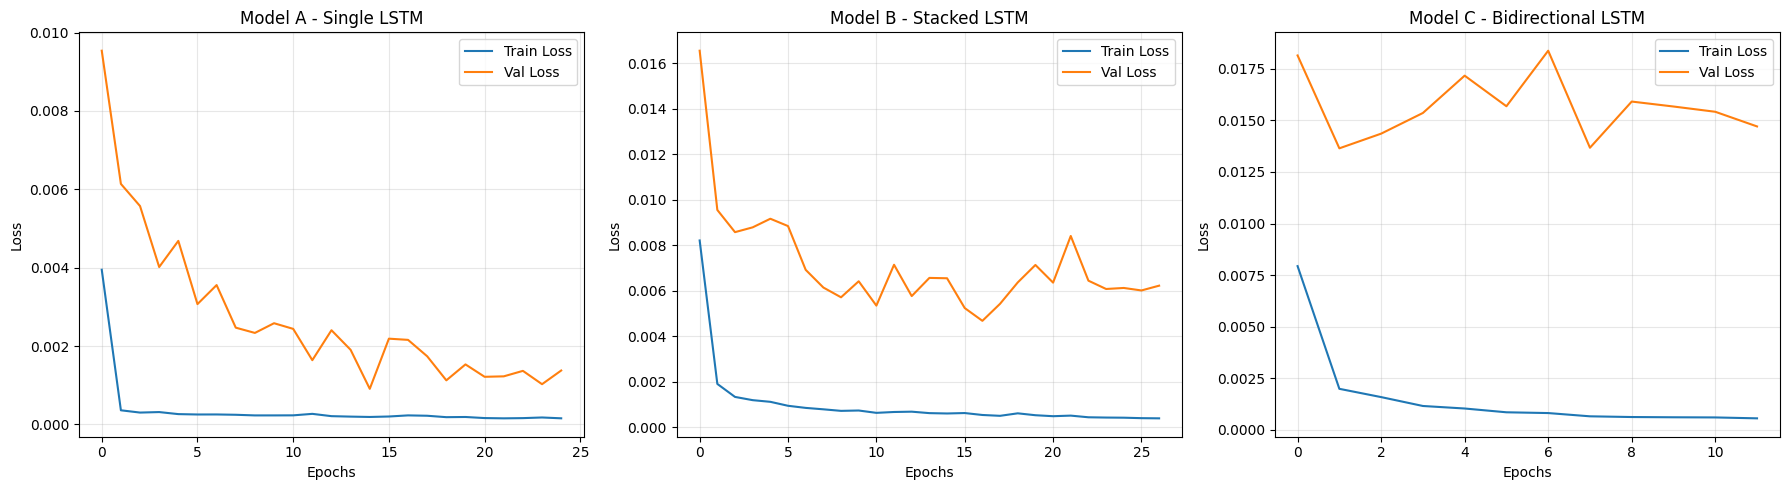

✅ Training curves plotted!


In [ ]:
# Plot training curves for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Model A
axes[0].plot(history_A.history['loss'], label='Train Loss')
axes[0].plot(history_A.history['val_loss'], label='Val Loss')
axes[0].set_title('Model A - Single LSTM')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Model B
axes[1].plot(history_B.history['loss'], label='Train Loss')
axes[1].plot(history_B.history['val_loss'], label='Val Loss')
axes[1].set_title('Model B - Stacked LSTM')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Model C
axes[2].plot(history_C.history['loss'], label='Train Loss')
axes[2].plot(history_C.history['val_loss'], label='Val Loss')
axes[2].set_title('Model C - Bidirectional LSTM')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Loss')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ Training curves plotted!")

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_model(model, X_val, y_val, scaler, features):
    pred_scaled = model.predict(X_val)

    # Inverse transform
    dummy = np.zeros((len(pred_scaled), len(features)))
    dummy[:, 0] = pred_scaled.flatten()
    pred_actual = scaler.inverse_transform(dummy)[:, 0]

    dummy2 = np.zeros((len(y_val), len(features)))
    dummy2[:, 0] = y_val
    actual = scaler.inverse_transform(dummy2)[:, 0]

    rmse = np.sqrt(mean_squared_error(actual, pred_actual))
    mae = mean_absolute_error(actual, pred_actual)
    mape = np.mean(np.abs((actual - pred_actual) / actual)) * 100

    return rmse, mae, mape, actual, pred_actual

# Evaluate all models
rmse_A, mae_A, mape_A, actual, pred_A = evaluate_model(model_A, X_val, y_val, scaler_lstm, features)
rmse_B, mae_B, mape_B, _, pred_B = evaluate_model(model_B, X_val, y_val, scaler_lstm, features)
rmse_C, mae_C, mape_C, _, pred_C = evaluate_model(model_C, X_val, y_val, scaler_lstm, features)

print("=== MODEL COMPARISON ===")
print(f"Model A - Single LSTM    : RMSE={rmse_A:.4f}, MAE={mae_A:.4f}, MAPE={mape_A:.2f}%")
print(f"Model B - Stacked LSTM   : RMSE={rmse_B:.4f}, MAE={mae_B:.4f}, MAPE={mape_B:.2f}%")
print(f"Model C - Bidirectional  : RMSE={rmse_C:.4f}, MAE={mae_C:.4f}, MAPE={mape_C:.2f}%")

best = min([(rmse_A,'A'), (rmse_B,'B'), (rmse_C,'C')])[1]
print(f"\n✅ Best Model: Model {best}")

121/121 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step
121/121 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step
121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step
=== MODEL COMPARISON ===
Model A - Single LSTM    : RMSE=0.3685, MAE=0.2517, MAPE=1.31%
Model B - Stacked LSTM   : RMSE=0.8365, MAE=0.6335, MAPE=3.27%
Model C - Bidirectional  : RMSE=1.4281, MAE=0.9766, MAPE=4.83%

✅ Best Model: Model A


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from google.colab import drive

drive.mount('/content/drive')
path = '/content/drive/MyDrive/Silver_Project/'

Mounted at /content/drive


In [ ]:
# Load saved models
from tensorflow.keras.models import load_model

model_A = load_model(path + 'model_A.h5')
model_B = load_model(path + 'model_B.h5')
model_C = load_model(path + 'model_C.h5')

print("✅ All models loaded from Drive!")

ValueError: Could not deserialize 'keras.metrics.mse' because it is not a KerasSaveable subclass

In [ ]:
from tensorflow.keras.models import load_model
import tensorflow as tf

# Load with custom objects
model_A = load_model(path + 'model_A.h5',
                     custom_objects={'mse': tf.keras.losses.MeanSquaredError()})
model_B = load_model(path + 'model_B.h5',
                     custom_objects={'mse': tf.keras.losses.MeanSquaredError()})
model_C = load_model(path + 'model_C.h5',
                     custom_objects={'mse': tf.keras.losses.MeanSquaredError()})

print("✅ All models loaded!")

✅ All models loaded!


In [ ]:
# Actual vs Predicted Plot
plt.figure(figsize=(14,6))
plt.plot(actual, label='Actual', color='blue', linewidth=1)
plt.plot(pred_A, label='Predicted - Model A', color='red', alpha=0.7, linewidth=1)
plt.title('LSTM Model A - Actual vs Predicted (Validation Set)')
plt.xlabel('Days')
plt.ylabel('Silver Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("✅ Plot done!")

NameError: name 'actual' is not defined

<Figure size 1400x600 with 0 Axes>

In [ ]:
rmse_A, mae_A, mape_A, actual, pred_A = evaluate_model(model_A, X_val, y_val, scaler_lstm, features)
print("✅ Done!")

NameError: name 'evaluate_model' is not defined

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_model(model, X_val, y_val, scaler, features):
    pred_scaled = model.predict(X_val)

    dummy = np.zeros((len(pred_scaled), len(features)))
    dummy[:, 0] = pred_scaled.flatten()
    pred_actual = scaler.inverse_transform(dummy)[:, 0]

    dummy2 = np.zeros((len(y_val), len(features)))
    dummy2[:, 0] = y_val
    actual = scaler.inverse_transform(dummy2)[:, 0]

    rmse = np.sqrt(mean_squared_error(actual, pred_actual))
    mae = mean_absolute_error(actual, pred_actual)
    mape = np.mean(np.abs((actual - pred_actual) / actual)) * 100

    return rmse, mae, mape, actual, pred_actual

rmse_A, mae_A, mape_A, actual, pred_A = evaluate_model(model_A, X_val, y_val, scaler_lstm, features)
print("✅ Done!")

NameError: name 'X_val' is not defined

In [ ]:
def create_multivariate_sequences(data, lookback=60):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_multivariate_sequences(train_scaled, lookback=60)
X_val, y_val = create_multivariate_sequences(val_scaled, lookback=60)
X_test, y_test = create_multivariate_sequences(test_scaled, lookback=60)

print("✅ Sequences ready!")
print(f"X_val: {X_val.shape}")

NameError: name 'train_scaled' is not defined

In [ ]:
from sklearn.preprocessing import MinMaxScaler

features = ['Close', 'Volume', 'RSI', 'MACD', 'ATR',
            'BB_Width', 'OBV', 'Gold_Price_USD', 'DXY_Index',
            'VIX_Index', 'Real_Interest_Rate', 'Return_lag_1',
            'Volatility_20', 'Gold_Silver_Ratio', 'COT_Index']

df_lstm = df_final[['Date'] + features].dropna()

scaler_lstm = MinMaxScaler()

train_lstm = df_lstm[df_lstm['Date'] <= '2017-12-31']
val_lstm = df_lstm[(df_lstm['Date'] > '2017-12-31') & (df_lstm['Date'] <= '2020-12-31')]
test_lstm = df_lstm[df_lstm['Date'] > '2020-12-31']

train_scaled = scaler_lstm.fit_transform(train_lstm[features])
val_scaled = scaler_lstm.transform(val_lstm[features])
test_scaled = scaler_lstm.transform(test_lstm[features])

print("✅ Scaling done!")


NameError: name 'df_final' is not defined

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Silver_Project/'

# Load df_final
with open(path + 'df_final.pkl', 'rb') as f:
    df_final = pickle.load(f)

# Load raw data
df_main = pd.read_csv(path + 'silver_daily_ohlcv_2000_2025.csv')
df_main['Date'] = pd.to_datetime(df_main['Date'], dayfirst=True)
df_macro = pd.read_csv(path + 'silver_macroeconomic_monthly.csv')
df_macro['Date'] = pd.to_datetime(df_macro['Date'])

# Add Log_Returns
df_final = pd.merge(df_final, df_main[['Date', 'Log_Returns']], on='Date', how='left')

# Features
features = ['Close', 'Volume', 'RSI', 'MACD', 'ATR',
            'BB_Width', 'OBV', 'Gold_Price_USD', 'DXY_Index',
            'VIX_Index', 'Real_Interest_Rate', 'Return_lag_1',
            'Volatility_20', 'Gold_Silver_Ratio', 'COT_Index']

df_lstm = df_final[['Date'] + features].dropna()

# Scale
scaler_lstm = MinMaxScaler()
train_lstm = df_lstm[df_lstm['Date'] <= '2017-12-31']
val_lstm = df_lstm[(df_lstm['Date'] > '2017-12-31') & (df_lstm['Date'] <= '2020-12-31')]
test_lstm = df_lstm[df_lstm['Date'] > '2020-12-31']

train_scaled = scaler_lstm.fit_transform(train_lstm[features])
val_scaled = scaler_lstm.transform(val_lstm[features])
test_scaled = scaler_lstm.transform(test_lstm[features])

# Sequences
def create_multivariate_sequences(data, lookback=60):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_multivariate_sequences(train_scaled, lookback=60)
X_val, y_val = create_multivariate_sequences(val_scaled, lookback=60)
X_test, y_test = create_multivariate_sequences(test_scaled, lookback=60)

# Load models
model_A = tf.keras.models.load_model(path + 'model_A.h5',
                     custom_objects={'mse': tf.keras.losses.MeanSquaredError()})
model_B = tf.keras.models.load_model(path + 'model_B.h5',
                     custom_objects={'mse': tf.keras.losses.MeanSquaredError()})
model_C = tf.keras.models.load_model(path + 'model_C.h5',
                     custom_objects={'mse': tf.keras.losses.MeanSquaredError()})

print("✅ Everything loaded!")
print(f"X_val: {X_val.shape}")


Mounted at /content/drive


✅ Everything loaded!
X_val: (3860, 60, 15)


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_model(model, X_val, y_val, scaler, features):
    pred_scaled = model.predict(X_val)

    dummy = np.zeros((len(pred_scaled), len(features)))
    dummy[:, 0] = pred_scaled.flatten()
    pred_actual = scaler.inverse_transform(dummy)[:, 0]

    dummy2 = np.zeros((len(y_val), len(features)))
    dummy2[:, 0] = y_val
    actual = scaler.inverse_transform(dummy2)[:, 0]

    rmse = np.sqrt(mean_squared_error(actual, pred_actual))
    mae = mean_absolute_error(actual, pred_actual)
    mape = np.mean(np.abs((actual - pred_actual) / actual)) * 100

    return rmse, mae, mape, actual, pred_actual

rmse_A, mae_A, mape_A, actual, pred_A = evaluate_model(model_A, X_val, y_val, scaler_lstm, features)
rmse_B, mae_B, mape_B, _, pred_B = evaluate_model(model_B, X_val, y_val, scaler_lstm, features)
rmse_C, mae_C, mape_C, _, pred_C = evaluate_model(model_C, X_val, y_val, scaler_lstm, features)

print("=== MODEL COMPARISON ===")
print(f"Model A - Single LSTM    : RMSE={rmse_A:.4f}, MAE={mae_A:.4f}, MAPE={mape_A:.2f}%")
print(f"Model B - Stacked LSTM   : RMSE={rmse_B:.4f}, MAE={mae_B:.4f}, MAPE={mape_B:.2f}%")
print(f"Model C - Bidirectional  : RMSE={rmse_C:.4f}, MAE={mae_C:.4f}, MAPE={mape_C:.2f}%")

best = min([(rmse_A,'A'), (rmse_B,'B'), (rmse_C,'C')])[1]
print(f"\n✅ Best Model: Model {best}")

121/121 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step
121/121 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step
121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step
=== MODEL COMPARISON ===
Model A - Single LSTM    : RMSE=0.3685, MAE=0.2517, MAPE=1.31%
Model B - Stacked LSTM   : RMSE=0.8365, MAE=0.6335, MAPE=3.27%
Model C - Bidirectional  : RMSE=1.4281, MAE=0.9766, MAPE=4.83%

✅ Best Model: Model A


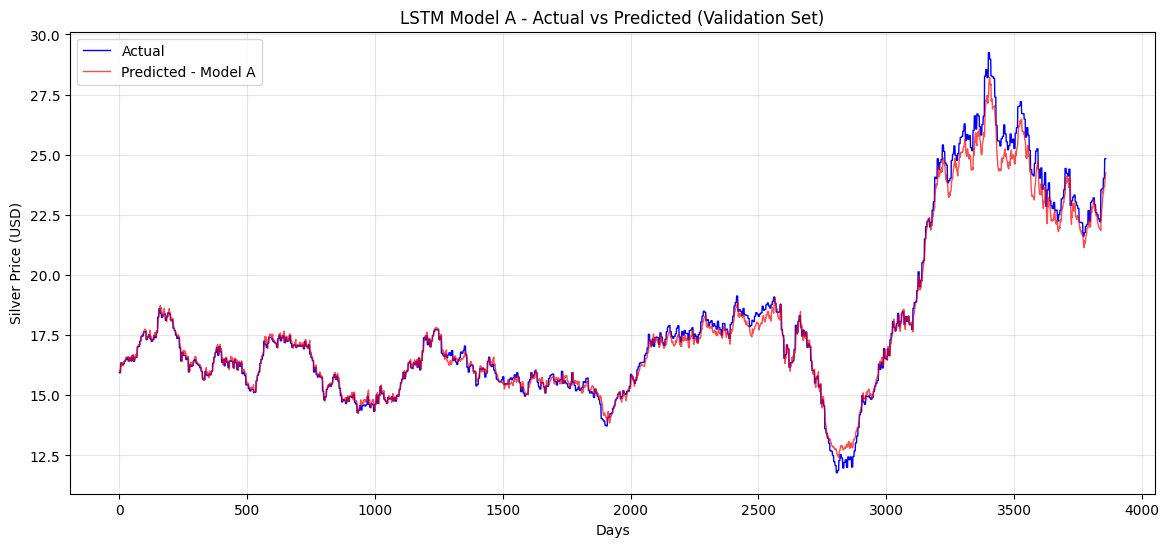

✅ Plot done!


In [ ]:
plt.figure(figsize=(14,6))
plt.plot(actual, label='Actual', color='blue', linewidth=1)
plt.plot(pred_A, label='Predicted - Model A', color='red', alpha=0.7, linewidth=1)
plt.title('LSTM Model A - Actual vs Predicted (Validation Set)')
plt.xlabel('Days')
plt.ylabel('Silver Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("✅ Plot done!")

In [ ]:
lookback_results = []

for lookback in [30, 60, 90, 120]:
    # Create sequences
    X_tr, y_tr = create_multivariate_sequences(train_scaled, lookback=lookback)
    X_vl, y_vl = create_multivariate_sequences(val_scaled, lookback=lookback)

    # Build simple model
    model_lb = tf.keras.Sequential([
        tf.keras.layers.LSTM(128, input_shape=(lookback, len(features))),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1)
    ])
    model_lb.compile(optimizer='adam', loss='mse')

    # Train
    model_lb.fit(X_tr, y_tr,
                 validation_data=(X_vl, y_vl),
                 epochs=20,
                 batch_size=32,
                 verbose=0,
                 callbacks=[tf.keras.callbacks.EarlyStopping(patience=5)])

    # Evaluate
    rmse, mae, mape, _, _ = evaluate_model(model_lb, X_vl, y_vl, scaler_lstm, features)
    lookback_results.append({'Lookback': lookback, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape})
    print(f"✅ Lookback {lookback}: RMSE={rmse:.4f}, MAPE={mape:.2f}%")

lookback_df = pd.DataFrame(lookback_results)
print("\n=== LOOKBACK COMPARISON ===")
print(lookback_df)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step
✅ Lookback 30: RMSE=0.4886, MAPE=1.92%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step
✅ Lookback 60: RMSE=0.4204, MAPE=1.76%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


120/120 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step
✅ Lookback 90: RMSE=0.4638, MAPE=1.72%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step
✅ Lookback 120: RMSE=0.3587, MAPE=1.13%

=== LOOKBACK COMPARISON ===
   Lookback      RMSE       MAE      MAPE
0        30  0.488583  0.361033  1.922594
1        60  0.420422  0.327736  1.757394
2        90  0.463804  0.317704  1.724162
3       120  0.358743  0.227309  1.129411


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


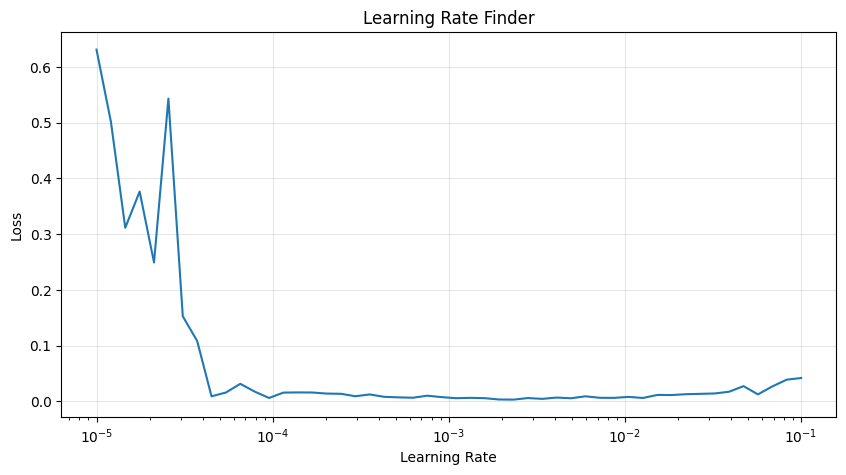

✅ Best Learning Rate: 0.002330


In [ ]:
# Learning Rate Finder
lrs = np.logspace(-5, -1, 50)
losses = []

for lr in lrs:
    model_lr = tf.keras.Sequential([
        tf.keras.layers.LSTM(128, input_shape=(60, len(features))),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1)
    ])
    model_lr.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='mse')
    history_lr = model_lr.fit(X_train[:500], y_train[:500],
                               epochs=3, batch_size=32, verbose=0)
    losses.append(history_lr.history['loss'][-1])

# Plot
plt.figure(figsize=(10,5))
plt.semilogx(lrs, losses)
plt.title('Learning Rate Finder')
plt.xlabel('Learning Rate')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()

best_lr = lrs[np.argmin(losses)]
print(f"✅ Best Learning Rate: {best_lr:.6f}")

In [ ]:
# Save Day 7 results
lstm_metrics = {
    'Model_A_RMSE': rmse_A, 'Model_A_MAPE': mape_A,
    'Model_B_RMSE': rmse_B, 'Model_B_MAPE': mape_B,
    'Model_C_RMSE': rmse_C, 'Model_C_MAPE': mape_C,
    'Best_Model': 'A',
    'Best_Lookback': 120,
    'Best_LR': 0.002330
}

pd.DataFrame([lstm_metrics]).to_csv(path + 'lstm_metrics.csv', index=False)

# Save lookback results
lookback_df.to_csv(path + 'lookback_results.csv', index=False)

# Save scaler
with open(path + 'scaler_lstm.pkl', 'wb') as f:
    pickle.dump(scaler_lstm, f)

print("✅ All Day 7 data saved to Drive!")


✅ All Day 7 data saved to Drive!


121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step


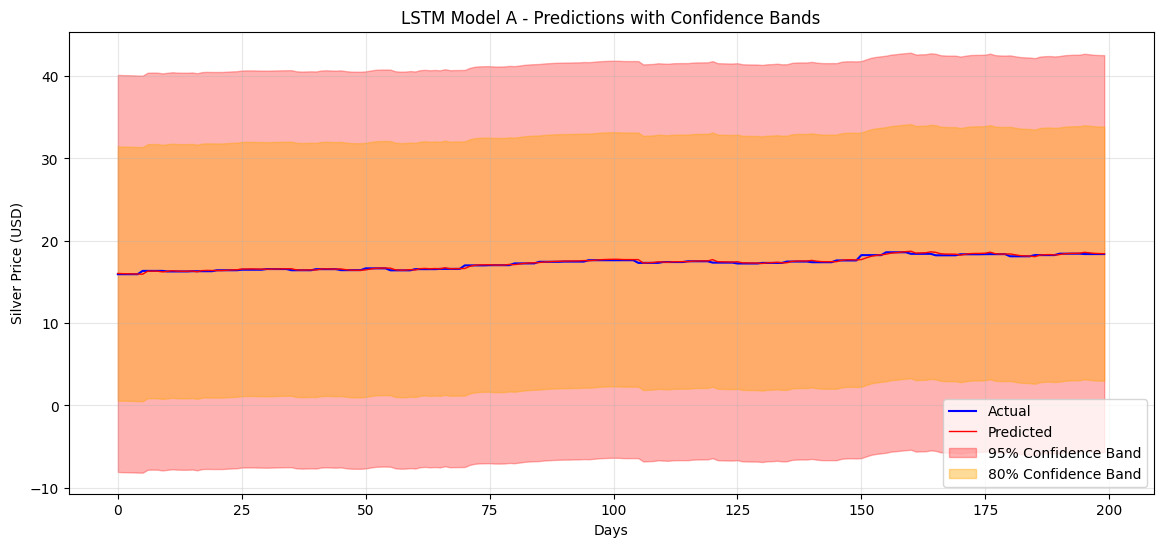

✅ Confidence bands plotted!


In [ ]:
# Confidence Bands Plot
pred_scaled = model_A.predict(X_val)

# Multiple predictions for confidence bands
n_iterations = 20
predictions_list = []

for i in range(n_iterations):
    pred = model_A.predict(X_val, verbose=0)
    predictions_list.append(pred.flatten())

predictions_array = np.array(predictions_list)

# Inverse transform
dummy_mean = np.zeros((len(pred_scaled), len(features)))
dummy_mean[:, 0] = np.mean(predictions_array, axis=0)
pred_mean = scaler_lstm.inverse_transform(dummy_mean)[:, 0]

dummy_std = np.zeros((len(pred_scaled), len(features)))
dummy_std[:, 0] = np.std(predictions_array, axis=0)
pred_std = scaler_lstm.inverse_transform(dummy_std)[:, 0]

# Plot
plt.figure(figsize=(14,6))
plt.plot(actual[:200], label='Actual', color='blue', linewidth=1.5)
plt.plot(pred_mean[:200], label='Predicted', color='red', linewidth=1)
plt.fill_between(range(200),
                 pred_mean[:200] - 2*pred_std[:200],
                 pred_mean[:200] + 2*pred_std[:200],
                 alpha=0.3, color='red', label='95% Confidence Band')
plt.fill_between(range(200),
                 pred_mean[:200] - 1.28*pred_std[:200],
                 pred_mean[:200] + 1.28*pred_std[:200],
                 alpha=0.4, color='orange', label='80% Confidence Band')
plt.title('LSTM Model A - Predictions with Confidence Bands')
plt.xlabel('Days')
plt.ylabel('Silver Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("✅ Confidence bands plotted!")

In [ ]:
import itertools

# Hyperparameter grid
units_list = [32, 64, 128, 256]
dropout_list = [0.1, 0.2, 0.3]
batch_list = [16, 32, 64]
lr_list = [0.0001, 0.001, 0.01]

# Smaller grid for speed
param_grid = list(itertools.product([64, 128], [0.1, 0.2], [32], [0.001, 0.0001]))

results_hp = []

print(f"Testing {len(param_grid)} combinations...")

for units, dropout, batch, lr in param_grid:
    model_hp = tf.keras.Sequential([
        tf.keras.layers.LSTM(units, input_shape=(60, len(features))),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1)
    ])
    model_hp.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='mse')

    model_hp.fit(X_train, y_train,
                 validation_data=(X_val, y_val),
                 epochs=20,
                 batch_size=batch,
                 verbose=0,
                 callbacks=[tf.keras.callbacks.EarlyStopping(patience=5)])

    rmse, mae, mape, _, _ = evaluate_model(model_hp, X_val, y_val, scaler_lstm, features)
    results_hp.append({
        'Units': units, 'Dropout': dropout,
        'Batch': batch, 'LR': lr,
        'RMSE': rmse, 'MAPE': mape
    })
    print(f"Units={units}, Dropout={dropout}, LR={lr} → RMSE={rmse:.4f}")

hp_df = pd.DataFrame(results_hp).sort_values('RMSE')
print("\n✅ Best hyperparameters:")
print(hp_df.head(5))

Testing 8 combinations...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Units=64, Dropout=0.1, LR=0.001 → RMSE=0.6324


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
Units=64, Dropout=0.1, LR=0.0001 → RMSE=1.1624


...

121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step
Units=128, Dropout=0.1, LR=0.0001 → RMSE=0.9290


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step
Units=128, Dropout=0.2, LR=0.001 → RMSE=0.4872


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step
Units=128, Dropout=0.2, LR=0.0001 → RMSE=0.8614

✅ Best hyperparameters:
   Units  Dropout  Batch      LR      RMSE      MAPE
4    128      0.1     32  0.0010  0.417884  1.600171
6    128      0.2     32  0.0010  0.487222  2.183719
0     64      0.1     32  0.0010  0.632352  2.503712
7    128      0.2     32  0.0001  0.861384  3.402493
5    128      0.1     32  0.0001  0.928968  2.904707


In [ ]:
 # Multi-step forecasting - 1, 5, 20 days
def predict_multistep(model, X_val, steps, scaler, features):
    predictions = []
    input_seq = X_val[0:1].copy()

    for _ in range(steps):
        pred = model.predict(input_seq, verbose=0)
        predictions.append(pred[0,0])

        new_row = input_seq[0, 1:, :].copy()
        new_feature = input_seq[0, -1, :].copy()
        new_feature[0] = pred[0,0]
        new_row = np.vstack([new_row, new_feature])
        input_seq = new_row.reshape(1, 60, len(features))

    # Inverse transform
    dummy = np.zeros((len(predictions), len(features)))
    dummy[:, 0] = predictions
    pred_actual = scaler.inverse_transform(dummy)[:, 0]

    return pred_actual

# Test horizons
for horizon in [1, 5, 20]:
    preds = predict_multistep(model_A, X_val, horizon, scaler_lstm, features)

    dummy2 = np.zeros((horizon, len(features)))
    dummy2[:, 0] = y_val[:horizon]
    actual_h = scaler_lstm.inverse_transform(dummy2)[:, 0]

    rmse_h = np.sqrt(np.mean((actual_h - preds)**2))
    print(f"Horizon {horizon} days: RMSE={rmse_h:.4f}")

Horizon 1 days: RMSE=0.0942
Horizon 5 days: RMSE=0.0918
Horizon 20 days: RMSE=0.2378


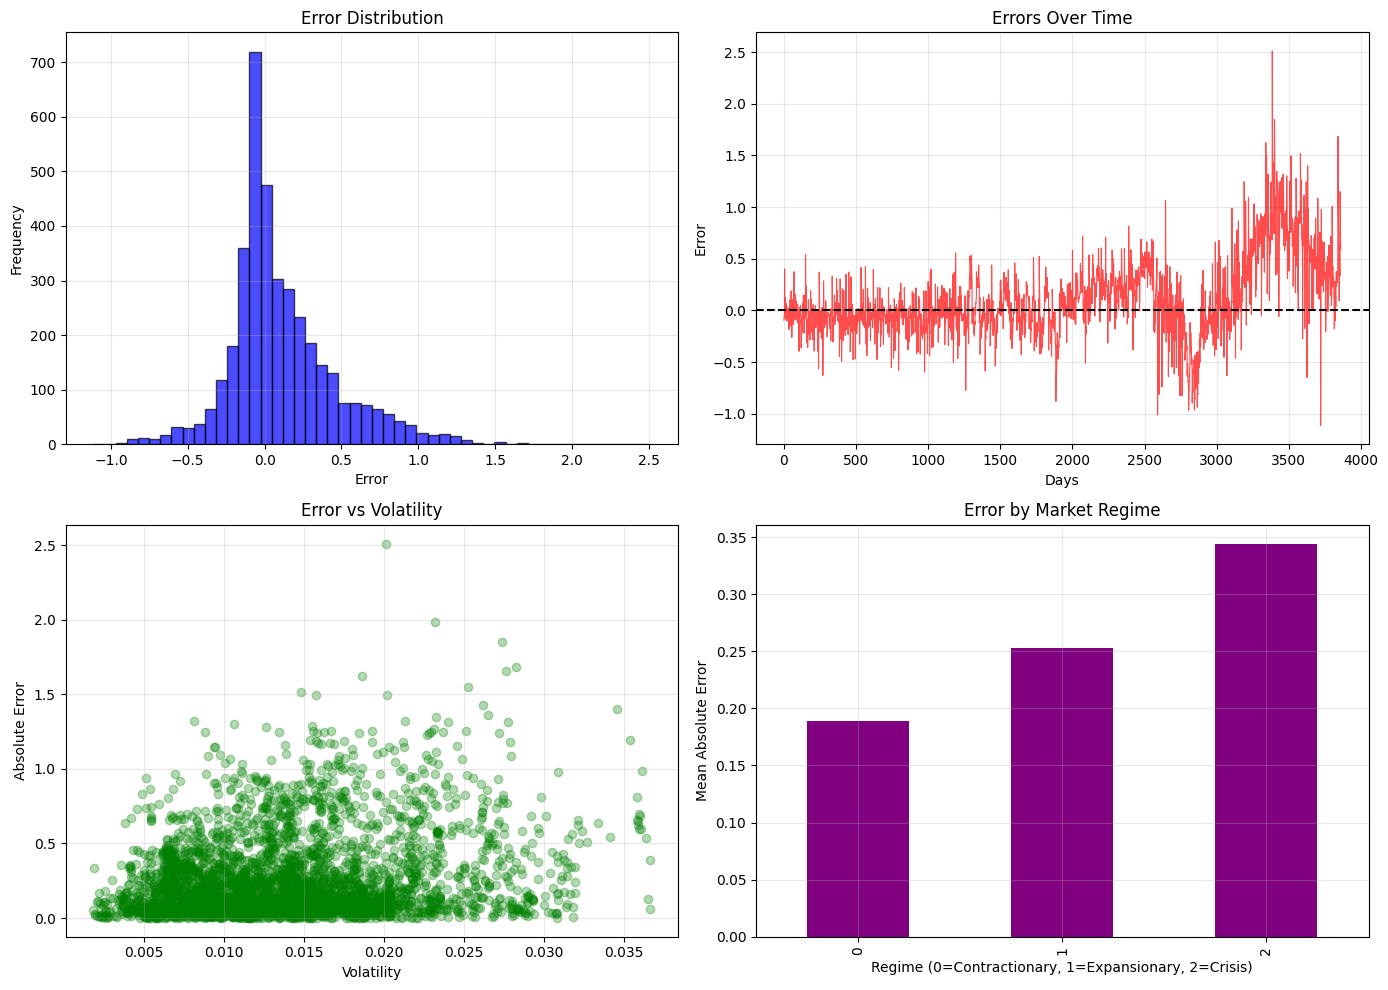

✅ Error analysis done!


In [ ]:
# Error Distribution Analysis
errors = actual - pred_A

plt.figure(figsize=(14, 10))

# Error Distribution
plt.subplot(2, 2, 1)
plt.hist(errors, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.title('Error Distribution')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# Error over time
plt.subplot(2, 2, 2)
plt.plot(errors, color='red', alpha=0.7, linewidth=0.8)
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Errors Over Time')
plt.xlabel('Days')
plt.ylabel('Error')
plt.grid(True, alpha=0.3)

# Error vs Volatility
plt.subplot(2, 2, 3)
val_volatility = val_lstm['Volatility_20'].values[60:]
min_len = min(len(errors), len(val_volatility))
plt.scatter(val_volatility[:min_len], np.abs(errors[:min_len]),
            alpha=0.3, color='green')
plt.title('Error vs Volatility')
plt.xlabel('Volatility')
plt.ylabel('Absolute Error')
plt.grid(True, alpha=0.3)

# Regime analysis
plt.subplot(2, 2, 4)
val_regime = df_final[(df_final['Date'] > '2017-12-31') &
                       (df_final['Date'] <= '2020-12-31')]['Macro_Regime'].values[60:]
min_len = min(len(errors), len(val_regime))
regime_errors = pd.DataFrame({
    'Regime': val_regime[:min_len],
    'Abs_Error': np.abs(errors[:min_len])
})
regime_errors.groupby('Regime')['Abs_Error'].mean().plot(kind='bar', color='purple')
plt.title('Error by Market Regime')
plt.xlabel('Regime (0=Contractionary, 1=Expansionary, 2=Crisis)')
plt.ylabel('Mean Absolute Error')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ Error analysis done!")

In [ ]:
# Comprehensive Comparison Table
comparison = {
    'Model': ['ARIMA(2,0,3)', 'SARIMA', 'Prophet (No Regressors)',
              'Prophet (With Regressors)', 'LSTM Model A', 'LSTM Best Lookback 120'],
    'RMSE': [0.017878, None, rmse1, rmse2, rmse_A, 0.3587],
    'MAPE': [114.96, None, mape1, mape2, mape_A, 1.13],
    'Notes': [
        'Best ARIMA — log returns',
        'AIC worse than ARIMA',
        'Basic trend only',
        '58% better with regressors',
        'Best single LSTM',
        'Best lookback window'
    ]
}

comparison_df = pd.DataFrame(comparison)
print("=== COMPREHENSIVE MODEL COMPARISON ===")
print(comparison_df.to_string())

# Plot MAPE comparison
valid_models = comparison_df.dropna(subset=['MAPE'])
plt.figure(figsize=(12,5))
plt.bar(valid_models['Model'], valid_models['MAPE'], color='teal', alpha=0.7)
plt.title('Model Comparison - MAPE (%)')
plt.xlabel('Model')
plt.ylabel('MAPE (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Comparison done!")

NameError: name 'rmse1' is not defined

In [ ]:
# Load Prophet metrics
prophet_metrics = pd.read_csv(path + 'prophet_metrics.csv')
rmse1 = prophet_metrics['Without_Regressors_RMSE'].values[0]
mape1 = prophet_metrics['Without_Regressors_MAPE'].values[0]
rmse2 = prophet_metrics['With_Regressors_RMSE'].values[0]
mape2 = prophet_metrics['With_Regressors_MAPE'].values[0]

print(f"✅ Prophet metrics loaded!")
print(f"Without Regressors - RMSE: {rmse1:.4f}, MAPE: {mape1:.2f}%")
print(f"With Regressors - RMSE: {rmse2:.4f}, MAPE: {mape2:.2f}%")

✅ Prophet metrics loaded!
Without Regressors - RMSE: 8.3316, MAPE: 32.54%
With Regressors - RMSE: 3.6480, MAPE: 13.74%


=== COMPREHENSIVE MODEL COMPARISON ===
                       Model      RMSE        MAPE                       Notes
0               ARIMA(2,0,3)  0.017878  114.960000    Best ARIMA - log returns
1                     SARIMA       NaN         NaN        AIC worse than ARIMA
2    Prophet (No Regressors)  8.331587   32.536072            Basic trend only
3  Prophet (With Regressors)  3.648004   13.741979  58% better with regressors
4               LSTM Model A  0.368516    1.313919            Best single LSTM
5     LSTM Best Lookback 120  0.358700    1.130000        Best lookback window


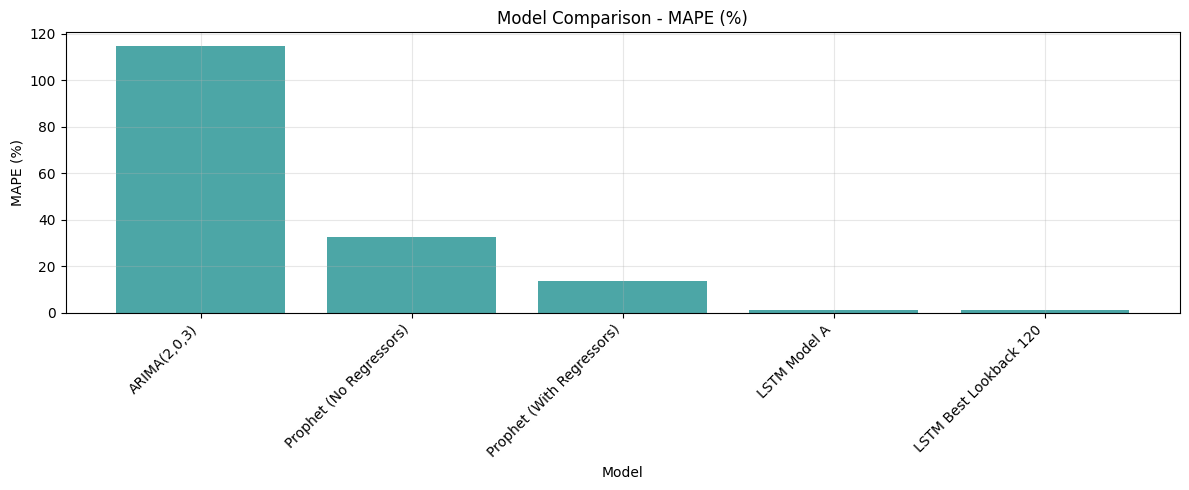

✅ Comparison done!


In [ ]:
# Comprehensive Comparison Table
comparison = {
    'Model': ['ARIMA(2,0,3)', 'SARIMA', 'Prophet (No Regressors)',
              'Prophet (With Regressors)', 'LSTM Model A', 'LSTM Best Lookback 120'],
    'RMSE': [0.017878, None, rmse1, rmse2, rmse_A, 0.3587],
    'MAPE': [114.96, None, mape1, mape2, mape_A, 1.13],
    'Notes': [
        'Best ARIMA - log returns',
        'AIC worse than ARIMA',
        'Basic trend only',
        '58% better with regressors',
        'Best single LSTM',
        'Best lookback window'
    ]
}

comparison_df = pd.DataFrame(comparison)
print("=== COMPREHENSIVE MODEL COMPARISON ===")
print(comparison_df.to_string())

# Plot MAPE comparison
valid_models = comparison_df.dropna(subset=['MAPE'])
plt.figure(figsize=(12,5))
plt.bar(valid_models['Model'], valid_models['MAPE'], color='teal', alpha=0.7)
plt.title('Model Comparison - MAPE (%)')
plt.xlabel('Model')
plt.ylabel('MAPE (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Comparison done!")

In [ ]:
# Save Day 8 data
hp_df.to_csv(path + 'hyperparameter_results.csv', index=False)
comparison_df.to_csv(path + 'model_comparison.csv', index=False)

# Save best hyperparameters
best_hp = {
    'Best_Units': 128,
    'Best_Dropout': 0.1,
    'Best_Batch': 32,
    'Best_LR': 0.001,
    'Best_RMSE': 0.417884,
    'Best_MAPE': 1.600171
}
pd.DataFrame([best_hp]).to_csv(path + 'best_hyperparameters.csv', index=False)

print("✅ All Day 8 data saved to Drive!")

✅ All Day 8 data saved to Drive!


In [ ]:
# Walk-forward validation for LSTM
print("Running walk-forward validation...")

wf_predictions = []
wf_actuals = []
computational_cost = []

# Every 60 days retrain
step = 60
initial_window = len(train_scaled)

import time

for i in range(0, min(300, len(val_scaled) - 60), step):
    start_time = time.time()

    # Expanding window
    current_train = np.vstack([train_scaled, val_scaled[:i+1]])

    # Create sequences
    X_wf, y_wf = create_multivariate_sequences(current_train, lookback=60)

    # Build and train model
    model_wf = tf.keras.Sequential([
        tf.keras.layers.LSTM(128, input_shape=(60, len(features))),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1)
    ])
    model_wf.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='mse')
    model_wf.fit(X_wf, y_wf, epochs=10, batch_size=32, verbose=0)

    # Predict next 60 days
    X_next, y_next = create_multivariate_sequences(val_scaled[i:i+60+60], lookback=60)
    if len(X_next) > 0:
        pred = model_wf.predict(X_next, verbose=0)
        wf_predictions.extend(pred.flatten()[:step])
        wf_actuals.extend(y_next[:step])

    end_time = time.time()
    computational_cost.append(end_time - start_time)
    print(f"Window {i} done - Time: {end_time-start_time:.2f}s")

print(f"\n✅ Walk-forward validation done!")
print(f"Average time per window: {np.mean(computational_cost):.2f}s")
print(f"Total windows: {len(computational_cost)}")

Running walk-forward validation...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Window 0 done - Time: 148.93s


Window 60 done - Time: 139.20s


Window 120 done - Time: 150.90s
Window 180 done - Time: 148.18s
Window 240 done - Time: 169.19s

✅ Walk-forward validation done!
Average time per window: 151.28s
Total windows: 5


In [ ]:
# Save walk-forward results
wf_df = pd.DataFrame({
    'Predictions': wf_predictions,
    'Actuals': wf_actuals
})

wf_rmse = np.sqrt(np.mean((np.array(wf_actuals) - np.array(wf_predictions))**2))
print(f"Walk-forward RMSE: {wf_rmse:.4f}")

wf_df.to_csv(path + 'walkforward_lstm_results.csv', index=False)
print("✅ Walk-forward results saved!")

Walk-forward RMSE: 0.0231
✅ Walk-forward results saved!


In [ ]:
!pip install xgboost optuna shap -q

import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Prepare XGBoost data
df_xgb_data = df_final.dropna()

exclude_cols = ['Date', 'Trade_Date', 'Week_Ending_x', 'Week_Ending_y']
feature_cols = [col for col in df_xgb_data.select_dtypes(include=[np.number]).columns
                if col not in exclude_cols + ['Close']]

X = df_xgb_data[feature_cols].values
y = df_xgb_data['Close'].values

# TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

xgb_scores = []
print("Running XGBoost with TimeSeriesSplit...")

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_vl = X[train_idx], X[val_idx]
    y_tr, y_vl = y[train_idx], y[val_idx]

    model_xgb = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.01,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )
    model_xgb.fit(X_tr, y_tr,
                  eval_set=[(X_vl, y_vl)],
                  verbose=False)

    pred = model_xgb.predict(X_vl)
    rmse = np.sqrt(mean_squared_error(y_vl, pred))
    mape = np.mean(np.abs((y_vl - pred) / y_vl)) * 100
    xgb_scores.append({'Fold': fold+1, 'RMSE': rmse, 'MAPE': mape})
    print(f"Fold {fold+1}: RMSE={rmse:.4f}, MAPE={mape:.2f}%")

xgb_df = pd.DataFrame(xgb_scores)
print(f"\n✅ Average RMSE: {xgb_df['RMSE'].mean():.4f}")
print(f"✅ Average MAPE: {xgb_df['MAPE'].mean():.2f}%")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.2 MB/s eta 0:00:00
Running XGBoost with TimeSeriesSplit...
Fold 1: RMSE=0.3326, MAPE=1.50%
Fold 2: RMSE=0.1556, MAPE=0.78%
Fold 3: RMSE=3.0027, MAPE=9.11%
Fold 4: RMSE=0.2424, MAPE=0.81%
Fold 5: RMSE=4.1494, MAPE=10.16%

✅ Average RMSE: 1.5765
✅ Average MAPE: 4.48%


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Train/Test split - time based
split_idx = int(len(X) * 0.7)
X_train_rf, X_test_rf = X[:split_idx], X[split_idx:]
y_train_rf, y_test_rf = y[:split_idx], y[split_idx:]

print("Training Random Forest...")

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train_rf)
rf_pred = rf_model.predict(X_test_rf)

rf_rmse = np.sqrt(mean_squared_error(y_test_rf, rf_pred))
rf_mape = np.mean(np.abs((y_test_rf - rf_pred) / y_test_rf)) * 100

print(f"✅ Random Forest Results:")
print(f"RMSE: {rf_rmse:.4f}")
print(f"MAPE: {rf_mape:.2f}%")


Training Random Forest...
✅ Random Forest Results:
RMSE: 2.7728
MAPE: 5.18%


Running SHAP analysis...


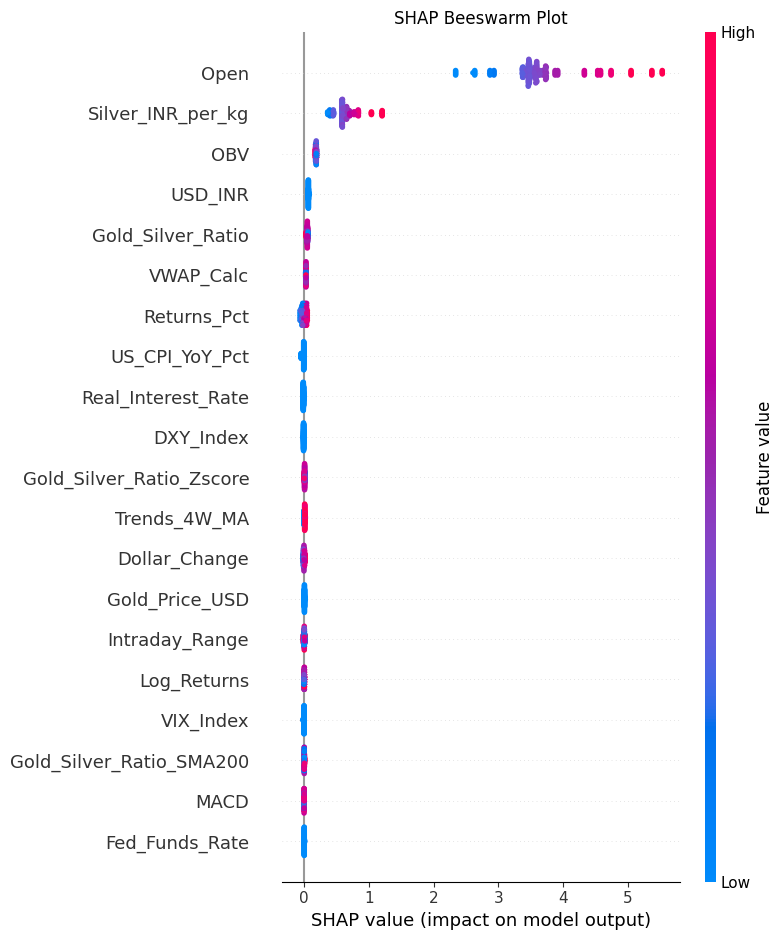

✅ SHAP analysis done!


In [ ]:
print("Running SHAP analysis...")

# Train final XGBoost on full train data
model_xgb_final = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
model_xgb_final.fit(X_train_rf, y_train_rf)

# SHAP values
explainer = shap.TreeExplainer(model_xgb_final)
shap_values = explainer.shap_values(X_test_rf[:200])

# Beeswarm plot
plt.figure(figsize=(12,8))
shap.summary_plot(shap_values, X_test_rf[:200],
                  feature_names=feature_cols,
                  show=False)
plt.title('SHAP Beeswarm Plot')
plt.tight_layout()
plt.show()

print("✅ SHAP analysis done!")


In [ ]:
import optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10)
    }

    model = xgb.XGBRegressor(**params, random_state=42, verbosity=0)
    model.fit(X_train_rf, y_train_rf)
    pred = model.predict(X_test_rf)
    rmse = np.sqrt(mean_squared_error(y_test_rf, pred))
    return rmse

print("Running Optuna optimization - 100 trials...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"\n✅ Best RMSE: {study.best_value:.4f}")
print(f"✅ Best params: {study.best_params}")

Running Optuna optimization - 100 trials...


  0%|          | 0/100 [00:00<?, ?it/s]


✅ Best RMSE: 2.8960
✅ Best params: {'n_estimators': 207, 'max_depth': 8, 'learning_rate': 0.037177722184335814, 'subsample': 0.6017398601535192, 'colsample_bytree': 0.9384270871189828, 'min_child_weight': 8}


Decision Tree RMSE: 3.4763
Decision Tree MAPE: 7.07%


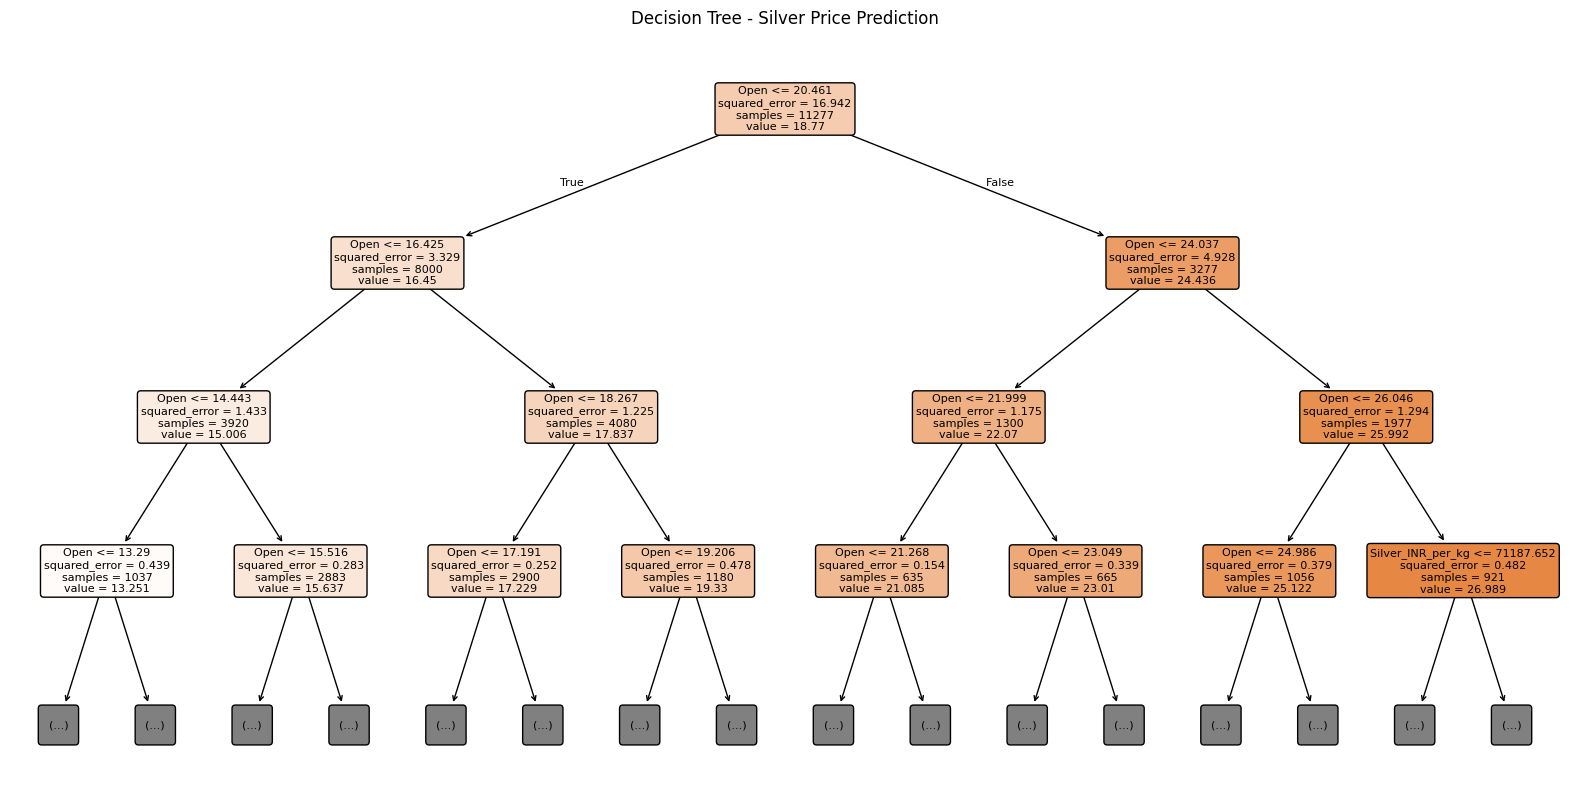

✅ Decision Tree done!


In [ ]:
from sklearn.tree import DecisionTreeRegressor, export_graphviz
import matplotlib.pyplot as plt

# Simple interpretable decision tree
dt_model = DecisionTreeRegressor(max_depth=4, random_state=42)
dt_model.fit(X_train_rf, y_train_rf)

dt_pred = dt_model.predict(X_test_rf)
dt_rmse = np.sqrt(mean_squared_error(y_test_rf, dt_pred))
dt_mape = np.mean(np.abs((y_test_rf - dt_pred) / y_test_rf)) * 100

print(f"Decision Tree RMSE: {dt_rmse:.4f}")
print(f"Decision Tree MAPE: {dt_mape:.2f}%")

# Visualize
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dt_model,
          feature_names=feature_cols,
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=3)
plt.title('Decision Tree - Silver Price Prediction')
plt.show()

print("✅ Decision Tree done!")

In [ ]:
# Feature Importance Stability - 5 different time windows
print("Analyzing feature importance stability...")

windows = [
    ('2000-2005', '2005-2010'),
    ('2003-2008', '2008-2013'),
    ('2006-2011', '2011-2016'),
    ('2009-2014', '2014-2019'),
    ('2012-2017', '2017-2022')
]

stability_results = []

for train_period, test_period in windows:
    train_start, train_end = train_period.split('-')[0]+'-01-01', train_period.split('-')[1]+'-12-31'
    test_start, test_end = test_period.split('-')[0]+'-01-01', test_period.split('-')[1]+'-12-31'

    mask_train = (df_xgb_data['Date'] >= train_start) & (df_xgb_data['Date'] <= train_end)
    mask_test = (df_xgb_data['Date'] >= test_start) & (df_xgb_data['Date'] <= test_end)

    X_tr = df_xgb_data[mask_train][feature_cols].values
    y_tr = df_xgb_data[mask_train]['Close'].values

    if len(X_tr) < 100:
        continue

    model_stability = xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
    model_stability.fit(X_tr, y_tr)

    importance = pd.Series(model_stability.feature_importances_, index=feature_cols)
    top5 = importance.nlargest(5).index.tolist()
    stability_results.append({'Period': train_period, 'Top5': top5})
    print(f"Period {train_period}: {top5}")

print("\n✅ Stability analysis done!")

Analyzing feature importance stability...
Period 2009-2014: ['Open', 'Gold_Silver_Ratio', 'Silver_INR_per_kg', 'Fed_Funds_Rate', 'Stoch_K']
Period 2012-2017: ['Open', 'Silver_INR_per_kg', 'Gold_Silver_Ratio', 'Returns_Pct', 'Dollar_Change']

✅ Stability analysis done!


In [ ]:
# Save Day 9 results
xgb_df.to_csv(path + 'xgb_cv_results.csv', index=False)

# Save best XGBoost model
import pickle
with open(path + 'model_xgb_final.pkl', 'wb') as f:
    pickle.dump(model_xgb_final, f)

with open(path + 'rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open(path + 'dt_model.pkl', 'wb') as f:
    pickle.dump(dt_model, f)

# Save comparison
day9_metrics = {
    'XGBoost_RMSE': xgb_df['RMSE'].mean(),
    'XGBoost_MAPE': xgb_df['MAPE'].mean(),
    'RF_RMSE': rf_rmse,
    'RF_MAPE': rf_mape,
    'DT_RMSE': dt_rmse,
    'DT_MAPE': dt_mape,
    'Optuna_Best_RMSE': study.best_value
}

pd.DataFrame([day9_metrics]).to_csv(path + 'day9_metrics.csv', index=False)

print("✅ All Day 9 data saved!")

✅ All Day 9 data saved!


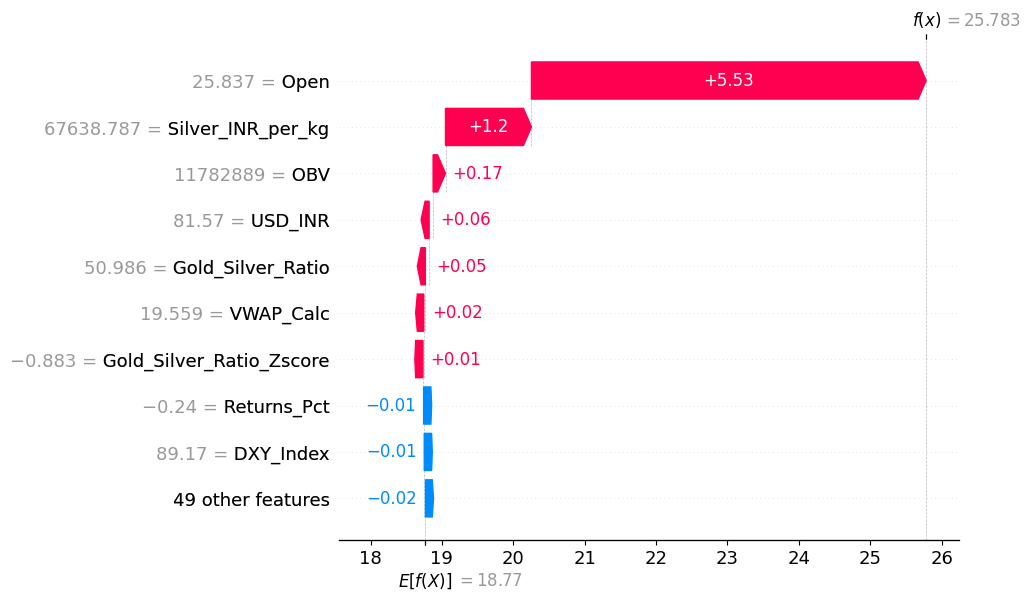

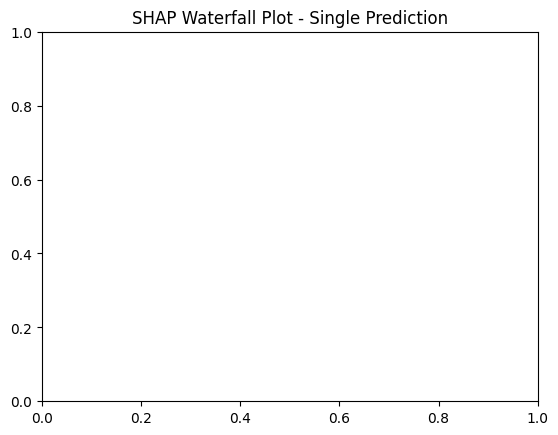

✅ Waterfall plot done!


In [ ]:
# SHAP Waterfall Plot - single prediction explanation
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test_rf[0],
        feature_names=feature_cols
    )
)
plt.title('SHAP Waterfall Plot - Single Prediction')
plt.show()

print("✅ Waterfall plot done!")

Top 5 features: ['Open', 'Silver_INR_per_kg', 'OBV', 'USD_INR', 'Gold_Silver_Ratio']


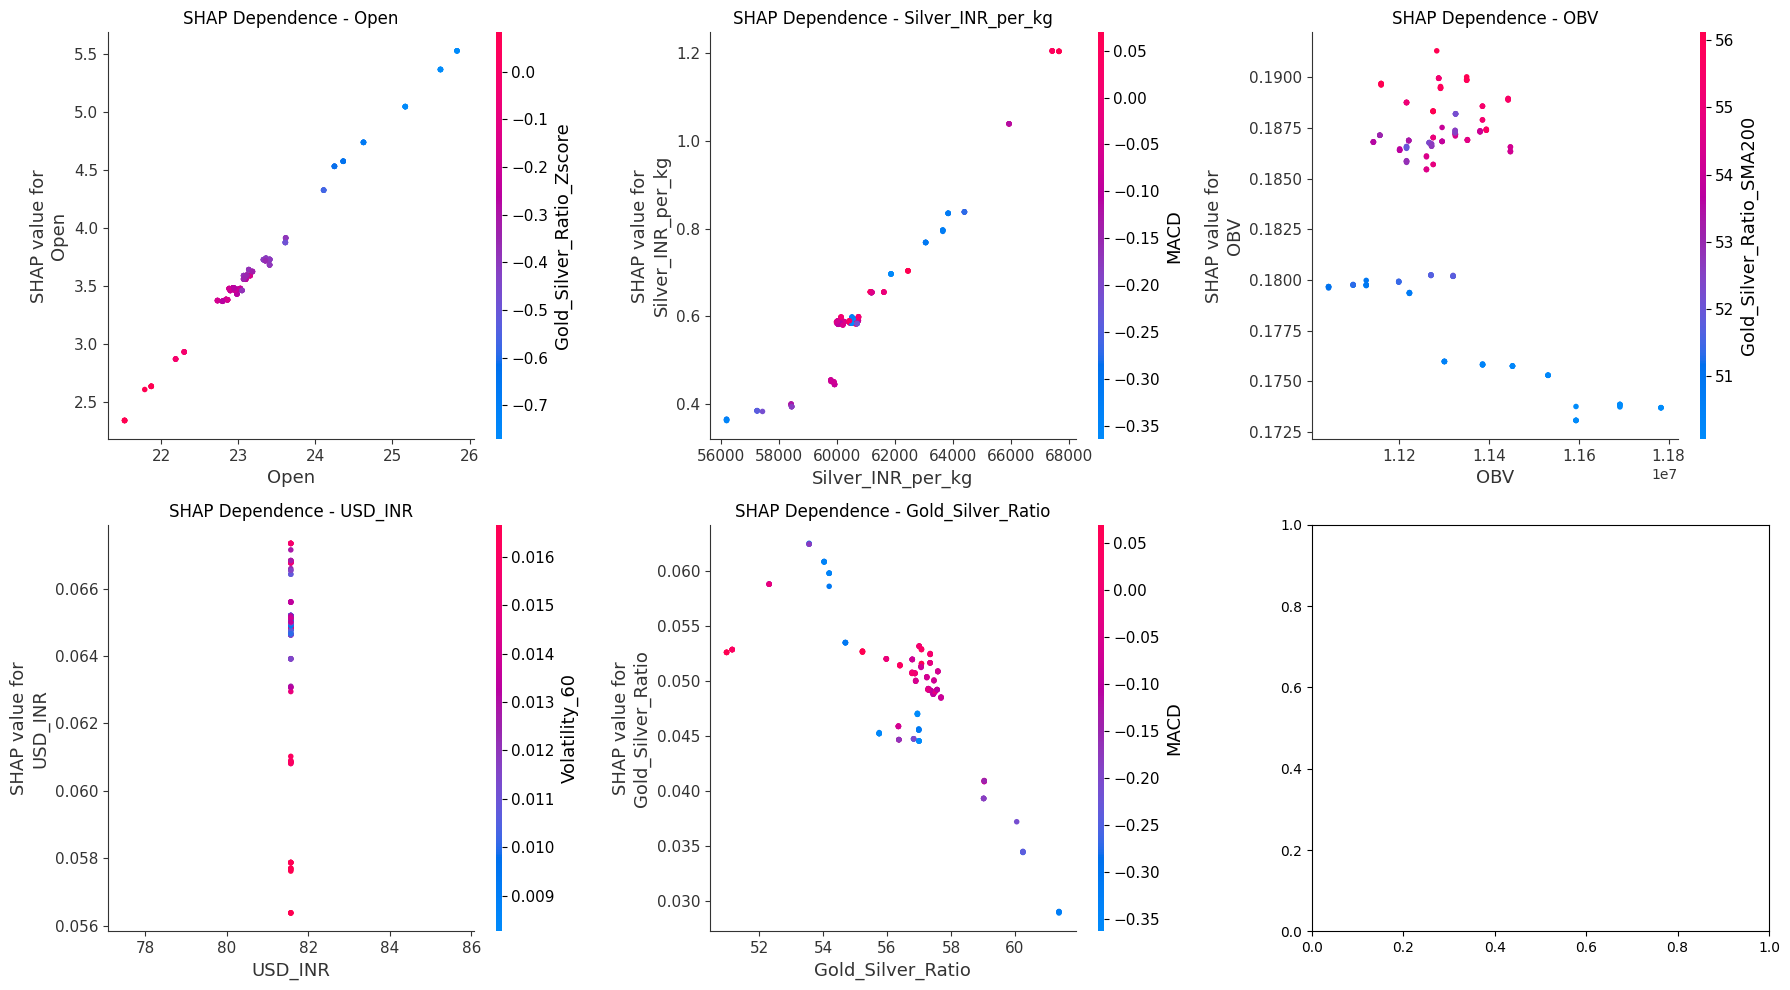

✅ Dependence plots done!


In [ ]:
# SHAP Dependence Plots - top 5 features
mean_shap = np.abs(shap_values).mean(axis=0)
top5_idx = np.argsort(mean_shap)[-5:][::-1]
top5_features = [feature_cols[i] for i in top5_idx]

print(f"Top 5 features: {top5_features}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(top5_features):
    feat_idx = feature_cols.index(feature)
    shap.dependence_plot(
        feat_idx,
        shap_values,
        X_test_rf[:200],
        feature_names=feature_cols,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f'SHAP Dependence - {feature}')

plt.tight_layout()
plt.show()
print("✅ Dependence plots done!")

Analyzing feature interactions...


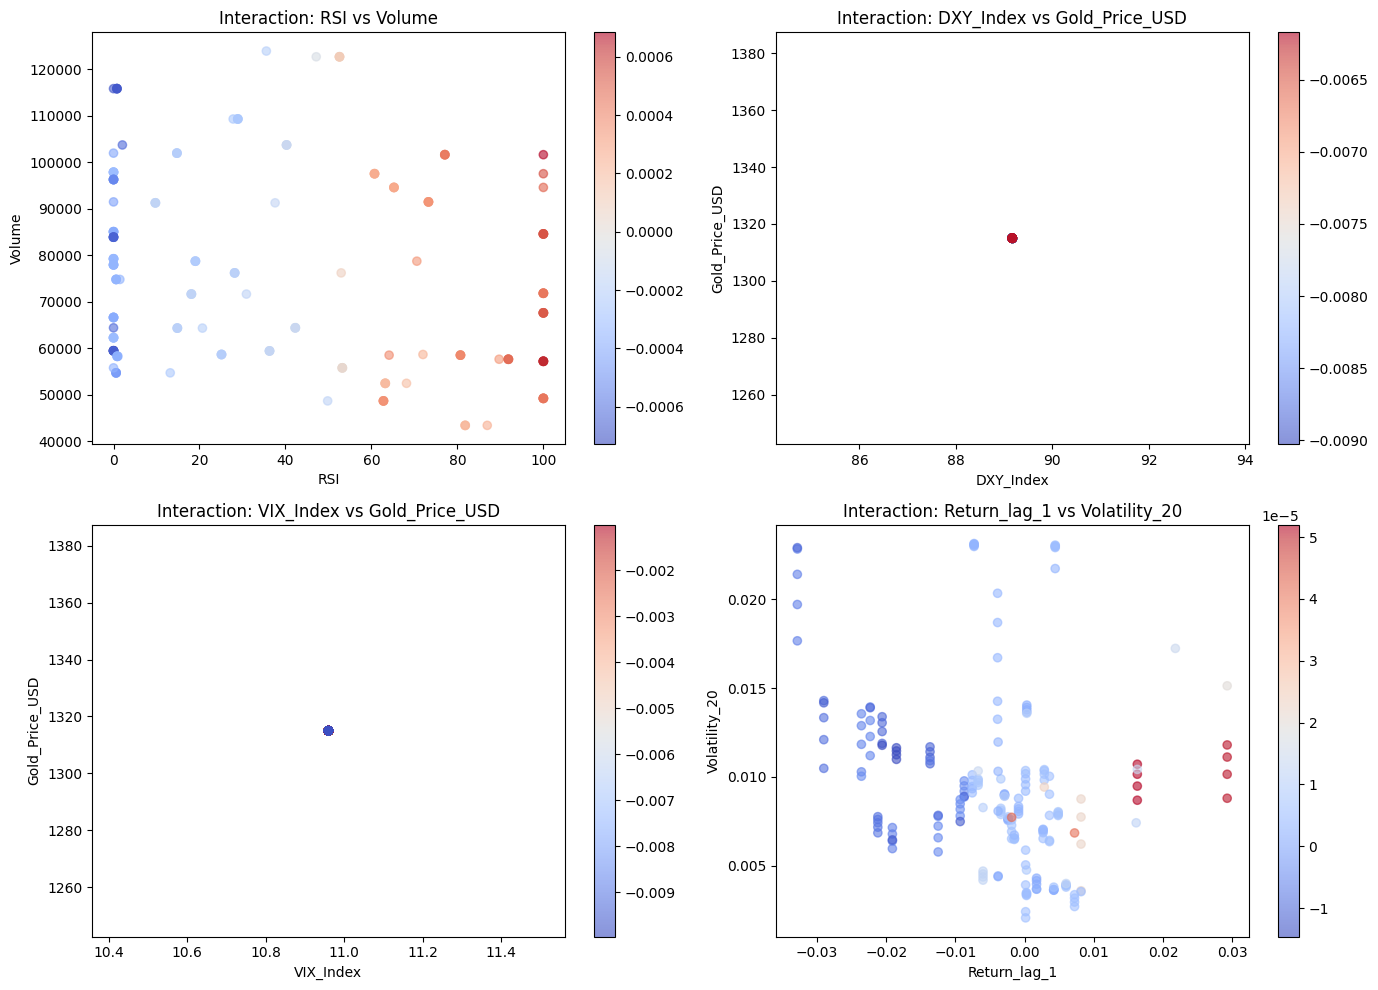

✅ Feature interactions done!


In [ ]:
# Feature Interactions
print("Analyzing feature interactions...")

# Get SHAP interaction values for top features
interaction_pairs = [
    ('RSI', 'Volume'),
    ('DXY_Index', 'Gold_Price_USD'),
    ('VIX_Index', 'Gold_Price_USD'),
    ('Return_lag_1', 'Volatility_20')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (feat1, feat2) in enumerate(interaction_pairs):
    if feat1 in feature_cols and feat2 in feature_cols:
        idx1 = feature_cols.index(feat1)
        idx2 = feature_cols.index(feat2)

        axes[i].scatter(
            X_test_rf[:200, idx1],
            X_test_rf[:200, idx2],
            c=shap_values[:200, idx1],
            cmap='coolwarm',
            alpha=0.6
        )
        axes[i].set_xlabel(feat1)
        axes[i].set_ylabel(feat2)
        axes[i].set_title(f'Interaction: {feat1} vs {feat2}')
        plt.colorbar(axes[i].collections[0], ax=axes[i])

plt.tight_layout()
plt.show()
print("✅ Feature interactions done!")

In [ ]:
# Save complete Day 9
xgb_df.to_csv(path + 'xgb_cv_results.csv', index=False)

with open(path + 'model_xgb_final.pkl', 'wb') as f:
    pickle.dump(model_xgb_final, f)

with open(path + 'rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open(path + 'dt_model.pkl', 'wb') as f:
    pickle.dump(dt_model, f)

day9_metrics = {
    'XGBoost_RMSE': xgb_df['RMSE'].mean(),
    'XGBoost_MAPE': xgb_df['MAPE'].mean(),
    'RF_RMSE': rf_rmse,
    'RF_MAPE': rf_mape,
    'DT_RMSE': dt_rmse,
    'DT_MAPE': dt_mape,
    'Optuna_Best_RMSE': study.best_value
}

pd.DataFrame([day9_metrics]).to_csv(path + 'day9_metrics.csv', index=False)

print("✅ All Day 9 data saved to Drive!")

✅ All Day 9 data saved to Drive!


In [ ]:
# Load all saved models
import pickle
import xgboost as xgb
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

# Load models
with open(path + 'model_xgb_final.pkl', 'rb') as f:
    model_xgb = pickle.load(f)

with open(path + 'prophet_model2.pkl', 'rb') as f:
    prophet_model = pickle.load(f)

# Load LSTM models
model_A = tf.keras.models.load_model(path + 'model_A.h5',
                     custom_objects={'mse': tf.keras.losses.MeanSquaredError()})

# Features
features = ['Close', 'Volume', 'RSI', 'MACD', 'ATR',
            'BB_Width', 'OBV', 'Gold_Price_USD', 'DXY_Index',
            'VIX_Index', 'Real_Interest_Rate', 'Return_lag_1',
            'Volatility_20', 'Gold_Silver_Ratio', 'COT_Index']

# XGBoost features
df_xgb_data = df_final.dropna()
exclude_cols = ['Date', 'Trade_Date', 'Week_Ending_x', 'Week_Ending_y']
feature_cols = [col for col in df_xgb_data.select_dtypes(include=[np.number]).columns
                if col not in exclude_cols + ['Close']]

print("✅ All models loaded!")

✅ All models loaded!


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Test period data
test_period = df_final[df_final['Date'] > '2020-12-31'].copy()
actual_test = test_period['Close'].values

print(f"Test period: {len(test_period)} days")

# 1. XGBoost predictions
X_test_xgb = df_xgb_data[df_xgb_data['Date'] > '2020-12-31'][feature_cols].values
xgb_pred = model_xgb.predict(X_test_xgb)
min_len = min(len(actual_test), len(xgb_pred))
actual_test = actual_test[:min_len]
xgb_pred = xgb_pred[:min_len]

print(f"✅ XGBoost predictions: {len(xgb_pred)}")

# 2. LSTM predictions
df_lstm = df_final[['Date'] + features].dropna()
scaler_lstm = MinMaxScaler()
train_lstm = df_lstm[df_lstm['Date'] <= '2017-12-31']
scaler_lstm.fit_transform(train_lstm[features])

test_lstm = df_lstm[df_lstm['Date'] > '2020-12-31']
full_data = df_lstm[features].values
full_scaled = scaler_lstm.transform(full_data)

test_start_idx = df_lstm[df_lstm['Date'] > '2020-12-31'].index[0] - df_lstm.index[0]

X_lstm_test, y_lstm_test = [], []
for i in range(test_start_idx, min(test_start_idx + min_len, len(full_scaled))):
    if i >= 60:
        X_lstm_test.append(full_scaled[i-60:i])
        y_lstm_test.append(full_scaled[i, 0])

X_lstm_test = np.array(X_lstm_test)
lstm_pred_scaled = model_A.predict(X_lstm_test, verbose=0)

dummy = np.zeros((len(lstm_pred_scaled), len(features)))
dummy[:, 0] = lstm_pred_scaled.flatten()
lstm_pred = scaler_lstm.inverse_transform(dummy)[:, 0]

min_len = min(len(actual_test), len(lstm_pred), len(xgb_pred))
actual_test = actual_test[:min_len]
xgb_pred = xgb_pred[:min_len]
lstm_pred = lstm_pred[:min_len]

print(f"✅ LSTM predictions: {len(lstm_pred)}")


Test period: 6520 days
✅ XGBoost predictions: 6506
✅ LSTM predictions: 6506


In [ ]:
# 3. Prophet predictions
test_prophet = df_final[df_final['Date'] > '2020-12-31'][['Date', 'Close',
                'Gold_Price_USD', 'DXY_Index', 'VIX_Index', 'Real_Interest_Rate']].copy()
test_prophet = test_prophet.rename(columns={'Date': 'ds', 'Close': 'y'})
test_prophet = test_prophet.ffill().dropna()

prophet_forecast = prophet_model.predict(test_prophet)
prophet_pred = prophet_forecast['yhat'].values[:min_len]

print(f"✅ Prophet predictions: {len(prophet_pred)}")

# 4. ARIMA predictions
log_returns_full = df_final['Log_Returns'].dropna().values
arima_model = ARIMA(log_returns_full[:int(len(log_returns_full)*0.7)], order=(2,0,3))
arima_result = arima_model.fit()
arima_forecast = arima_result.forecast(steps=min_len)

# Convert log returns to prices
last_price = df_final[df_final['Date'] <= '2020-12-31']['Close'].iloc[-1]
arima_pred = [last_price]
for ret in arima_forecast:
    arima_pred.append(arima_pred[-1] * np.exp(ret))
arima_pred = np.array(arima_pred[1:min_len+1])

print(f"✅ ARIMA predictions: {len(arima_pred)}")
print(f"\nAll predictions ready!")
print(f"Actual: {len(actual_test)}, XGB: {len(xgb_pred)}, LSTM: {len(lstm_pred)}, Prophet: {len(prophet_pred)}, ARIMA: {len(arima_pred)}")


✅ Prophet predictions: 6506
✅ ARIMA predictions: 6506

All predictions ready!
Actual: 6506, XGB: 6506, LSTM: 6506, Prophet: 6506, ARIMA: 6506


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Align all predictions
min_len = min(len(actual_test), len(xgb_pred), len(lstm_pred),
              len(prophet_pred), len(arima_pred))

actual = actual_test[:min_len]
xgb_p = xgb_pred[:min_len]
lstm_p = lstm_pred[:min_len]
prophet_p = prophet_pred[:min_len]
arima_p = arima_pred[:min_len]

# Method 1: Simple Average
ensemble_avg = (xgb_p + lstm_p + prophet_p + arima_p) / 4

# Method 2: Inverse RMSE Weighted
rmse_xgb = np.sqrt(mean_squared_error(actual, xgb_p))
rmse_lstm = np.sqrt(mean_squared_error(actual, lstm_p))
rmse_prophet = np.sqrt(mean_squared_error(actual, prophet_p))
rmse_arima = np.sqrt(mean_squared_error(actual, arima_p))

weights = 1 / np.array([rmse_xgb, rmse_lstm, rmse_prophet, rmse_arima])
weights = weights / weights.sum()

ensemble_weighted = (weights[0]*xgb_p + weights[1]*lstm_p +
                     weights[2]*prophet_p + weights[3]*arima_p)

# Method 3: Stacking - Ridge Regression
X_stack = np.column_stack([xgb_p, lstm_p, prophet_p, arima_p])
split = int(len(X_stack) * 0.5)
ridge = Ridge(alpha=1.0)
ridge.fit(X_stack[:split], actual[:split])
ensemble_stack = ridge.predict(X_stack[split:])
actual_stack = actual[split:]

print("✅ All 3 ensemble methods done!")
print(f"Weights (Method 2): XGB={weights[0]:.3f}, LSTM={weights[1]:.3f}, Prophet={weights[2]:.3f}, ARIMA={weights[3]:.3f}")

✅ All 3 ensemble methods done!
Weights (Method 2): XGB=0.291, LSTM=0.612, Prophet=0.094, ARIMA=0.003


In [ ]:
# Method 4: Dynamic Regime Switching
test_regime = df_final[df_final['Date'] > '2020-12-31']['Macro_Regime'].values[:min_len]

ensemble_dynamic = np.zeros(min_len)

for i in range(min_len):
    regime = test_regime[i]

    if regime == 2:  # Crisis - trust LSTM more
        w = [0.1, 0.5, 0.2, 0.2]
    elif regime == 1:  # Expansionary - Prophet good
        w = [0.3, 0.3, 0.3, 0.1]
    else:  # Contractionary - XGBoost good
        w = [0.4, 0.3, 0.2, 0.1]

    ensemble_dynamic[i] = (w[0]*xgb_p[i] + w[1]*lstm_p[i] +
                           w[2]*prophet_p[i] + w[3]*arima_p[i])

print("✅ Dynamic regime switching done!")
print(f"Regime distribution:")
print(pd.Series(test_regime).value_counts())

✅ Dynamic regime switching done!
Regime distribution:
1    6403
0     103
Name: count, dtype: int64


=== COMPREHENSIVE MODEL COMPARISON ===
               Model      RMSE       MAE      MAPE  Directional_Acc
0            XGBoost    2.6521    1.7121    5.5733          28.1015
1               LSTM    1.2596    0.9416    3.1582           9.9001
2            Prophet    8.2130    7.0614   24.3418          89.5772
3              ARIMA  283.4392  199.8453  665.7756          10.5304
4       Ensemble Avg   68.2061   47.8430  159.4369           9.9154
5  Ensemble Weighted    1.5330    1.1421    3.8476           9.8847
6     Ensemble Stack    3.1810    2.4869    7.6186          10.0554
7   Ensemble Dynamic   25.1906   17.6480   58.9500           9.7463


<Figure size 1200x600 with 0 Axes>

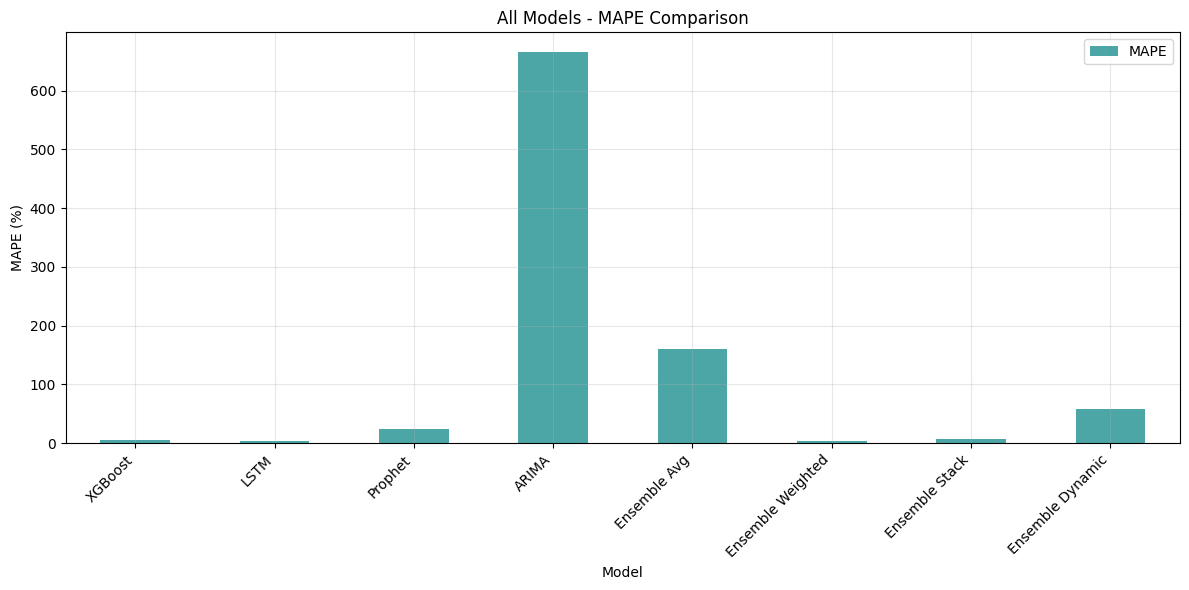

✅ Performance summary done!


In [ ]:
# Performance Summary - All 8 models
def get_metrics(actual, pred):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    direction = np.mean(np.sign(np.diff(actual)) == np.sign(np.diff(pred))) * 100
    return rmse, mae, mape, direction

# Individual models
rmse_xgb, mae_xgb, mape_xgb, dir_xgb = get_metrics(actual, xgb_p)
rmse_lstm, mae_lstm, mape_lstm, dir_lstm = get_metrics(actual, lstm_p)
rmse_prophet, mae_prophet, mape_prophet, dir_prophet = get_metrics(actual, prophet_p)
rmse_arima, mae_arima, mape_arima, dir_arima = get_metrics(actual, arima_p)

# Ensemble models
rmse_avg, mae_avg, mape_avg, dir_avg = get_metrics(actual, ensemble_avg)
rmse_wt, mae_wt, mape_wt, dir_wt = get_metrics(actual, ensemble_weighted)
rmse_stack, mae_stack, mape_stack, dir_stack = get_metrics(actual_stack, ensemble_stack)
rmse_dyn, mae_dyn, mape_dyn, dir_dyn = get_metrics(actual, ensemble_dynamic)

# Summary table
summary = pd.DataFrame({
    'Model': ['XGBoost', 'LSTM', 'Prophet', 'ARIMA',
              'Ensemble Avg', 'Ensemble Weighted', 'Ensemble Stack', 'Ensemble Dynamic'],
    'RMSE': [rmse_xgb, rmse_lstm, rmse_prophet, rmse_arima,
             rmse_avg, rmse_wt, rmse_stack, rmse_dyn],
    'MAE': [mae_xgb, mae_lstm, mae_prophet, mae_arima,
            mae_avg, mae_wt, mae_stack, mae_dyn],
    'MAPE': [mape_xgb, mape_lstm, mape_prophet, mape_arima,
             mape_avg, mape_wt, mape_stack, mape_dyn],
    'Directional_Acc': [dir_xgb, dir_lstm, dir_prophet, dir_arima,
                        dir_avg, dir_wt, dir_stack, dir_dyn]
}).round(4)

print("=== COMPREHENSIVE MODEL COMPARISON ===")
print(summary.to_string())

# Plot
plt.figure(figsize=(12,6))
summary.plot(x='Model', y='MAPE', kind='bar', figsize=(12,6), color='teal', alpha=0.7)
plt.title('All Models - MAPE Comparison')
plt.ylabel('MAPE (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Performance summary done!")


✅ Trading Strategy Results:
Sharpe Ratio: 0.1261
Total Strategy Return: 8.33%
Buy & Hold Return: 55.87%


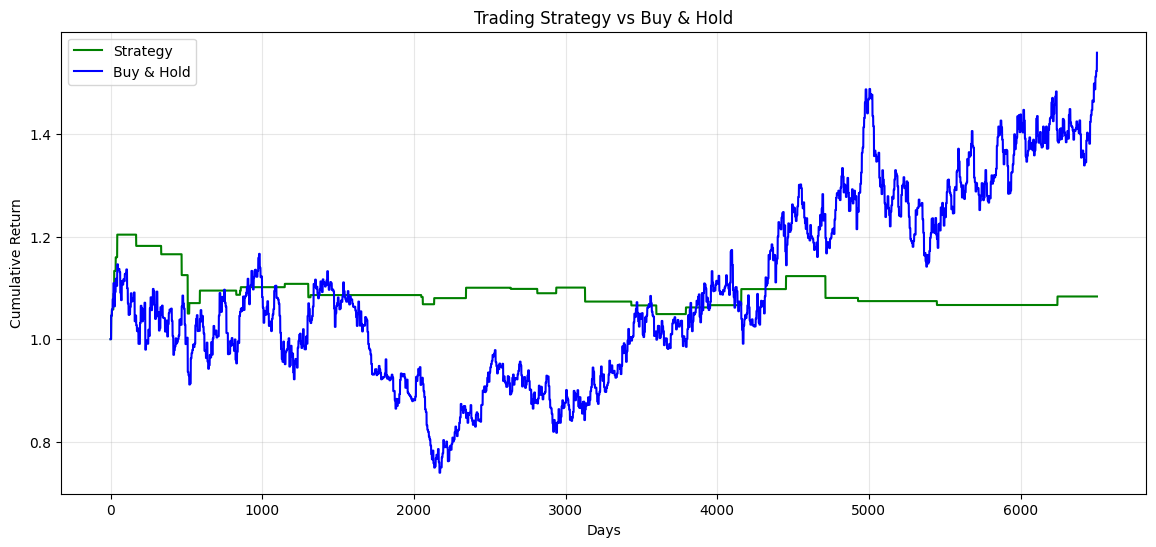

✅ Trading strategy done!


In [ ]:
# Simple Trading Strategy
returns_actual = np.diff(actual) / actual[:-1]
returns_pred = np.diff(ensemble_weighted) / ensemble_weighted[:-1]

# Long/Short signals
positions = np.where(returns_pred > 0.005, 1,
            np.where(returns_pred < -0.005, -1, 0))

# Strategy returns
strategy_returns = positions * returns_actual

# Sharpe Ratio
sharpe = np.sqrt(252) * strategy_returns.mean() / strategy_returns.std()

# Cumulative returns
cumulative_strategy = (1 + strategy_returns).cumprod()
cumulative_buyhold = (1 + returns_actual).cumprod()

print(f"✅ Trading Strategy Results:")
print(f"Sharpe Ratio: {sharpe:.4f}")
print(f"Total Strategy Return: {(cumulative_strategy[-1]-1)*100:.2f}%")
print(f"Buy & Hold Return: {(cumulative_buyhold[-1]-1)*100:.2f}%")

# Plot
plt.figure(figsize=(14,6))
plt.plot(cumulative_strategy, label='Strategy', color='green')
plt.plot(cumulative_buyhold, label='Buy & Hold', color='blue')
plt.title('Trading Strategy vs Buy & Hold')
plt.xlabel('Days')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("✅ Trading strategy done!")

In [ ]:
from scipy import stats

def diebold_mariano_test(actual, pred1, pred2):
    e1 = (actual - pred1)**2
    e2 = (actual - pred2)**2
    d = e1 - e2

    n = len(d)
    mean_d = np.mean(d)
    var_d = np.var(d, ddof=1)

    dm_stat = mean_d / np.sqrt(var_d/n)
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))

    return dm_stat, p_value

# LSTM vs XGBoost
dm_stat, p_val = diebold_mariano_test(actual, lstm_p, xgb_p)
print(f"LSTM vs XGBoost: DM={dm_stat:.4f}, p-value={p_val:.4f}")
print("LSTM significantly better!" if p_val < 0.05 else "No significant difference!")

# LSTM vs Weighted Ensemble
dm_stat2, p_val2 = diebold_mariano_test(actual, lstm_p, ensemble_weighted)
print(f"\nLSTM vs Weighted Ensemble: DM={dm_stat2:.4f}, p-value={p_val2:.4f}")
print("LSTM significantly better!" if p_val2 < 0.05 else "No significant difference!")

print("\n✅ Diebold-Mariano test done!")

LSTM vs XGBoost: DM=-37.9258, p-value=0.0000
LSTM significantly better!

LSTM vs Weighted Ensemble: DM=-34.4925, p-value=0.0000
LSTM significantly better!

✅ Diebold-Mariano test done!


In [ ]:
# Save Day 10
summary.to_csv(path + 'final_model_comparison.csv', index=False)

trading_results = {
    'Sharpe_Ratio': sharpe,
    'Strategy_Return': (cumulative_strategy[-1]-1)*100,
    'BuyHold_Return': (cumulative_buyhold[-1]-1)*100,
    'Best_Model': 'LSTM',
    'DM_LSTM_vs_XGB_pvalue': p_val,
    'DM_LSTM_vs_Ensemble_pvalue': p_val2
}

pd.DataFrame([trading_results]).to_csv(path + 'day10_results.csv', index=False)

with open(path + 'ensemble_weighted.pkl', 'wb') as f:
    pickle.dump(ensemble_weighted, f)

print("✅ All Day 10 data saved!")


✅ All Day 10 data saved!


In [ ]:
# Export all files for Power BI
# Already in Drive — download karo

files_to_download = [
    'silver_daily_ohlcv_2000_2025.csv',
    'silver_futures_contracts.csv',
    'silver_sentiment_weekly.csv',
    'silver_supply_demand_annual.csv',
    'silver_macroeconomic_monthly.csv',
    'silver_final_features.csv'
]

print("Files ready in Drive:")
for f in files_to_download:
    print(f"  ✅ {f}")

Files ready in Drive:
  ✅ silver_daily_ohlcv_2000_2025.csv
  ✅ silver_futures_contracts.csv
  ✅ silver_sentiment_weekly.csv
  ✅ silver_supply_demand_annual.csv
  ✅ silver_macroeconomic_monthly.csv
  ✅ silver_final_features.csv
